# 06 Statistical, uncertainty, transfer and decision analysis

This notebook evaluates paired model differences, uncertainty, telemetry perturbations, transfer and candidate-action feasibility.

The test set was examined during model development and supports exploratory comparisons. Paired uncertainty resamples topologies, not individual rows. Nine groups limit precision. Practical margins are declared as 0.001 p.u. mean voltage absolute error and 5 kW mean loss absolute error; these are study criteria, not utility-certified economic thresholds. Holm adjustment covers all paired target/baseline tests.

Probability maps and residual intervals use the reserved calibration role. Conditional coverage experiments are diagnostic and do not guarantee exchangeability under topology shift. Computational profiling is CPU process-level measurement, not embedded-hardware validation.

**Method reference.** Residual calibration follows the split-conformal principle described by [Angelopoulos and Bates](https://arxiv.org/abs/2107.07511); its exchangeability assumption is not guaranteed across withheld electrical topologies.

With nine topology groups and 18 comparisons, the smallest possible two-sided exact Wilcoxon p-value is 2/512; the first Holm threshold is 0.05/18. Thus this conservative family cannot yield a 5% rejection even with perfectly aligned signs. Effect estimates and cluster intervals remain descriptive; additional independent topologies are needed for a more informative confirmatory test. Practical support additionally requires the Holm criterion.

In [1]:
from pathlib import Path
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT = Path.cwd()
if PROJECT.name == "notebooks":
    PROJECT = PROJECT.parent
assert (PROJECT / "src" / "models.py").is_file()
sys.path.insert(0, str(PROJECT))
from src.notebook_tools import configure_style, show_table, save_figure
from src.protocol import SEED, SEEDS, FULL_CONFIG, TRAINING, MODEL_ORDER

configure_style()
rng = np.random.default_rng(SEED)
FIGURES = PROJECT / "figures"
TABLES = PROJECT / "artifacts" / "generated" / "tables"
RESULTS = PROJECT / "artifacts" / "generated" / "results"
MODELS = PROJECT / "artifacts" / "generated" / "models"
for directory in (FIGURES, TABLES, RESULTS, MODELS):
    directory.mkdir(parents=True, exist_ok=True)


from src.models import DatasetBundle, load_bundle, split_indices, predict_graph_model
from src.protocol import (
    regression_metrics,
    probability_metrics,
    fit_tabular,
    predict_tabular,
    train_graph,
    save_graph,
    inner_group_selection,
    measure_resources,
    cluster_bootstrap,
    holm_adjust,
    calibrate_probability,
)

bundle = load_bundle(PROJECT / "dataset" / "processed")
metadata = bundle.metadata
indices = split_indices(bundle)
all_indices = np.arange(len(metadata))
valid_test = indices["test"][metadata.iloc[indices["test"]].converged.to_numpy() == 1]
fold_manifest = pd.read_csv(PROJECT / "dataset" / "processed" / "topology_folds.csv")
fold_id = fold_manifest.set_index("sample_id").loc[metadata.sample_id, "fold"].to_numpy()


def prediction_path(name: str) -> Path:
    """Use the same unambiguous model identifier throughout the study."""
    return RESULTS / (name.replace(" ", "_") + "_predictions.npz")


def load_predictions(name: str) -> tuple[np.ndarray, np.ndarray]:
    stored = np.load(prediction_path(name))
    assert np.array_equal(stored["sample_id"], metadata.sample_id.to_numpy())
    return stored["prediction"], stored["probability"]

In [2]:
from dataclasses import replace
from scipy.stats import wilcoxon, spearmanr
from sklearn.calibration import calibration_curve
from sklearn.metrics import f1_score, roc_curve, precision_recall_curve, confusion_matrix
from sklearn.linear_model import LogisticRegression, Ridge
from scipy.special import logit
from src.experiments import load_graph_checkpoint, conformal_intervals
from src.models import DatasetBundle
from src.benchmarks import case33, CASE33_EDGE_DATA
from src.gridstudy import (
    generate_load_state,
    corrupt_telemetry,
    enumerate_case33_topologies,
    radial_power_flow,
    build_node_features,
    scenario_tabular_features,
    graph_matrices,
)
from src.experiments import build_candidate_bundle

members = [load_graph_checkpoint(MODELS / f"ACG_MAC_{seed}.pt", bundle) for seed in SEEDS]
prediction, probability = load_predictions("ACG-MAC Ensemble")
truth = bundle.targets
test_groups = metadata.iloc[valid_test].topology_id.to_numpy()


def ensemble_predict(
    selected_bundle: DatasetBundle, selected_indices: np.ndarray
) -> tuple[np.ndarray, np.ndarray]:
    """Average predictions of all five prespecified saved members."""
    outputs = [
        predict_graph_model(member, selected_bundle, selected_indices) for member in members
    ]
    return np.mean([output[0] for output in outputs], axis=0), np.mean(
        [output[1] for output in outputs], axis=0
    )

In [3]:
def cluster_bootstrap(
    delta: np.ndarray, groups: np.ndarray, seed: int = SEED, draws: int = 2000
) -> tuple[float, float, float]:
    """Resample independent topologies, retaining all their observations."""
    rng = np.random.default_rng(seed)
    unique = np.unique(groups)
    sums = np.array([delta[groups == group].sum() for group in unique])
    counts = np.array([(groups == group).sum() for group in unique])
    sampled = rng.integers(0, len(unique), (draws, len(unique)))
    means = sums[sampled].sum(axis=1) / counts[sampled].sum(axis=1)
    return (
        float(delta.mean()),
        float(np.quantile(means, 0.025)),
        float(np.quantile(means, 0.975)),
    )


def holm_adjust(pvalues: np.ndarray) -> np.ndarray:
    """Control familywise error across the declared paired comparisons."""
    order = np.argsort(pvalues)
    adjusted = np.maximum.accumulate(
        np.asarray(pvalues)[order] * (len(pvalues) - np.arange(len(pvalues)))
    )
    result = np.empty(len(pvalues))
    result[order] = np.minimum(1, adjusted)
    return result

## Paired topology-aware effects

Error differences are paired within electrical configurations.

In [4]:
rows = []
for name in MODEL_ORDER[:-1]:
    baseline_prediction, _ = load_predictions(name)
    for target, column, margin in [("Vmin MAE", 0, 0.001), ("Loss MAE kW", 1, 5.0)]:
        delta = np.abs(truth[valid_test, column] - prediction[valid_test, column]) - np.abs(
            truth[valid_test, column] - baseline_prediction[valid_test, column]
        )
        mean, low, high = cluster_bootstrap(delta, test_groups)
        group_effects = np.array(
            [delta[test_groups == group].mean() for group in np.unique(test_groups)]
        )
        pvalue = (
            float(wilcoxon(group_effects, method="exact").pvalue)
            if np.any(group_effects)
            else 1.0
        )
        rows.append(
            dict(
                model="ACG-MAC Ensemble",
                baseline=name,
                split="test converged",
                n=len(valid_test),
                target=target,
                mean_difference=mean,
                ci_low=low,
                ci_high=high,
                topologies=len(group_effects),
                p_raw=pvalue,
                practical_margin=margin,
                practical_gain_supported=bool(high < -margin),
            )
        )
statistics = pd.DataFrame(rows)
statistics["p_holm"] = holm_adjust(statistics.p_raw.to_numpy())
statistics["practical_gain_supported"] &= statistics.p_holm.lt(0.05)
statistics.to_csv(RESULTS / "paired_statistics.csv", index=False)
show_table(
    statistics,
    ["model", "baseline", "split", "n", "target"],
    {
        "Paired effect (negative favors ACG-MAC)": ["mean_difference", "ci_low", "ci_high"],
        "Group-level inference": ["topologies", "p_raw", "p_holm"],
        "Declared practical relevance": ["practical_margin", "practical_gain_supported"],
    },
    TABLES / "06_statistics.csv",
    digits=6,
)

model,baseline,split,n,target,mean_difference,ci_low,ci_high
ACG-MAC Ensemble,LinearDistFlow,test converged,605,Vmin MAE,−0.006567,−0.014588,−0.001754
ACG-MAC Ensemble,LinearDistFlow,test converged,605,Loss MAE kW,−33.655327,−77.120124,−9.760863
ACG-MAC Ensemble,Ridge,test converged,605,Vmin MAE,−0.001038,−0.002574,−0.000171
ACG-MAC Ensemble,Ridge,test converged,605,Loss MAE kW,−8.293966,−13.523493,−3.620196
ACG-MAC Ensemble,RandomForest,test converged,605,Vmin MAE,−0.001785,−0.004547,−0.000348
ACG-MAC Ensemble,RandomForest,test converged,605,Loss MAE kW,−7.320694,−22.841069,0.232721
ACG-MAC Ensemble,ExtraTrees,test converged,605,Vmin MAE,−0.003571,−0.010566,−0.000191
ACG-MAC Ensemble,ExtraTrees,test converged,605,Loss MAE kW,−19.742763,−62.301636,0.536300
ACG-MAC Ensemble,MLP,test converged,605,Vmin MAE,−0.003041,−0.005402,−0.001704
ACG-MAC Ensemble,MLP,test converged,605,Loss MAE kW,−1.817404,−3.945941,0.707827


Paired comparisons use topology-cluster intervals and a single Holm correction across both targets and all baselines. None of the adjusted tests rejects at the 5% level. Effect intervals describe the magnitude and uncertainty of differences.

In [5]:
def calibrate_probability(
    truth: np.ndarray, calibration_probability: np.ndarray, target_probability: np.ndarray
) -> tuple[np.ndarray, float, object]:
    """Fit Platt map and F1 threshold exclusively on the calibration role."""
    features = logit(np.clip(calibration_probability, 1e-6, 1 - 1e-6)).reshape(-1, 1)
    mapper = LogisticRegression(C=1.0, max_iter=1000).fit(features, truth)
    calibrated = mapper.predict_proba(features)[:, 1]
    thresholds = np.linspace(0.05, 0.95, 181)
    scores = [f1_score(truth, calibrated >= threshold) for threshold in thresholds]
    threshold = float(thresholds[int(np.argmax(scores))])
    target_features = logit(np.clip(target_probability, 1e-6, 1 - 1e-6)).reshape(-1, 1)
    return mapper.predict_proba(target_features)[:, 1], threshold, mapper

## Calibrated probability comparison

Calibration maps are fitted separately from the discrimination models.

In [6]:
calibration = indices["calibration"]
selected = indices["test"]
probability_rows = []
calibrated_probabilities = {}
thresholds = {}
for name in MODEL_ORDER:
    _, raw_probability = load_predictions(name)
    calibrated, threshold, mapper = calibrate_probability(
        truth[calibration, 2], raw_probability[calibration], raw_probability[selected]
    )
    calibrated_probabilities[name] = calibrated
    thresholds[name] = threshold
    import joblib

    joblib.dump(
        dict(mapper=mapper, threshold=threshold),
        MODELS / (name.replace(" ", "_") + "_calibration.joblib"),
    )
    for state, values, cutoff in [
        ("raw", raw_probability[selected], 0.5),
        ("Platt calibrated", calibrated, threshold),
    ]:
        probability_rows.append(
            dict(
                model=name,
                split="test",
                n=len(selected),
                state=state,
                threshold=cutoff,
                **probability_metrics(truth[selected, 2], values, cutoff)
            )
        )
calibration_results = pd.DataFrame(probability_rows)
calibration_results.to_csv(RESULTS / "calibrated_probability.csv", index=False)
np.savez_compressed(
    RESULTS / "calibrated_test_probabilities.npz",
    **{name: values for name, values in calibrated_probabilities.items()}
)
show_table(
    calibration_results,
    ["model", "split", "n", "state"],
    {
        "Discrimination ↑": ["auroc", "auprc", "f1"],
        "Probability errors ↓": ["brier", "log_loss", "ece"],
        "Calibration and decision rule": ["calibration_slope", "threshold"],
    },
    TABLES / "06_probability.csv",
    digits=6,
)

model,split,n,state,auroc,auprc,f1
LinearDistFlow,test,618,raw,0.992901,0.946970,0.972763
LinearDistFlow,test,618,Platt calibrated,0.992901,0.946970,0.972763
Ridge,test,618,raw,0.998118,0.992582,0.915751
Ridge,test,618,Platt calibrated,0.998118,0.992582,0.945736
RandomForest,test,618,raw,0.999838,0.999372,0.984252
RandomForest,test,618,Platt calibrated,0.999838,0.999372,0.984127
ExtraTrees,test,618,raw,0.998523,0.994313,0.949416
ExtraTrees,test,618,Platt calibrated,0.998523,0.994313,0.949416
MLP,test,618,raw,0.999059,0.996535,0.942529
MLP,test,618,Platt calibrated,0.999059,0.996535,0.942529


Platt maps and thresholds use only the calibration split. Test labels are used solely for scoring. Better AUROC does not imply calibrated probabilities, and calibration under one topology distribution may fail on another.

## Calibration and discrimination curves

Reliability, ROC and precision–recall curves describe complementary classifier properties.

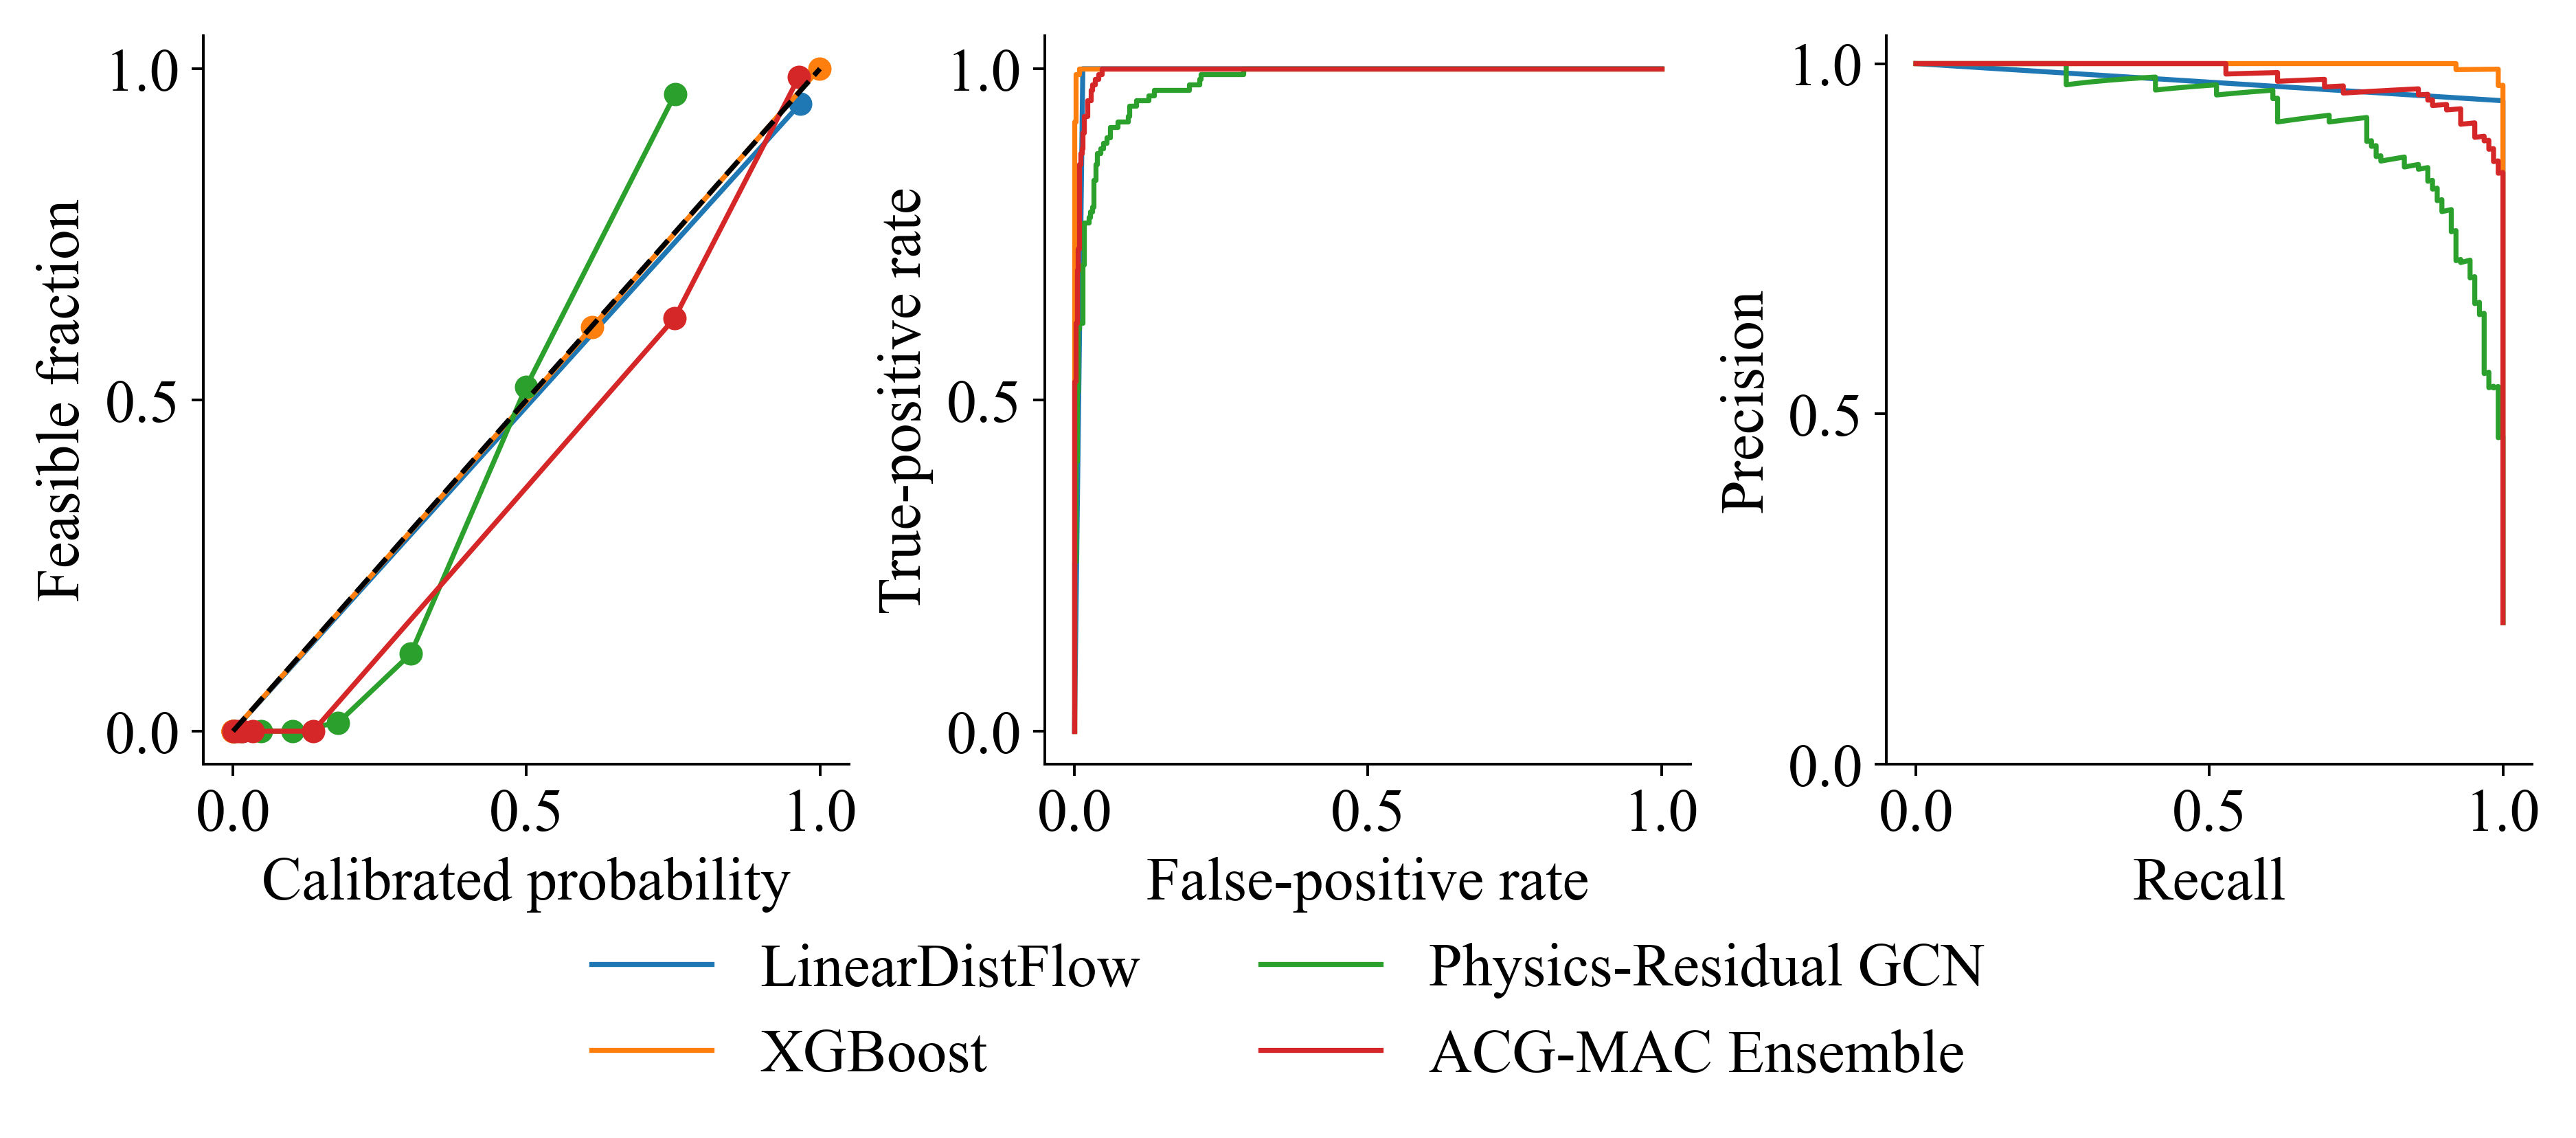

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(10.5, 4.6), layout="constrained")
curve_rows = []
for name in ["LinearDistFlow", "XGBoost", "Physics-Residual GCN", "ACG-MAC Ensemble"]:
    values = calibrated_probabilities[name]
    observed, confidence = calibration_curve(
        truth[selected, 2], values, n_bins=8, strategy="quantile"
    )
    axes[0].plot(confidence, observed, marker="o", label=name)
    false_positive, true_positive, _ = roc_curve(truth[selected, 2], values)
    precision, recall, _ = precision_recall_curve(truth[selected, 2], values)
    axes[1].plot(false_positive, true_positive, label=name)
    axes[2].plot(recall, precision, label=name)
    curve_rows.extend(
        dict(model=name, mean_probability=x, observed_fraction=y)
        for x, y in zip(confidence, observed)
    )
axes[0].plot([0, 1], [0, 1], "k--")
axes[0].set(xlabel="Calibrated probability", ylabel="Feasible fraction")
axes[1].set(xlabel="False-positive rate", ylabel="True-positive rate")
axes[2].set(xlabel="Recall", ylabel="Precision")
legend_handles, legend_labels = axes[2].get_legend_handles_labels()
fig.legend(legend_handles, legend_labels, loc="outside lower center", ncol=2, frameon=False)
for panel in axes:
    panel.set_xticks([0, 0.5, 1])
    panel.set_yticks([0, 0.5, 1])
save_figure(fig, FIGURES / "9_Feasibility_calibration_and_discrimination.png")
plt.show()
pd.DataFrame(curve_rows).to_csv(TABLES / "06_calibration_source.csv", index=False)

The three panels address probability reliability, ranking discrimination and precision–recall trade-offs. Feasibility means numerical convergence plus voltage limits only; thermal security is outside the labels.

## Confusion structure

The confusion matrix separates missed and falsely accepted operating states.

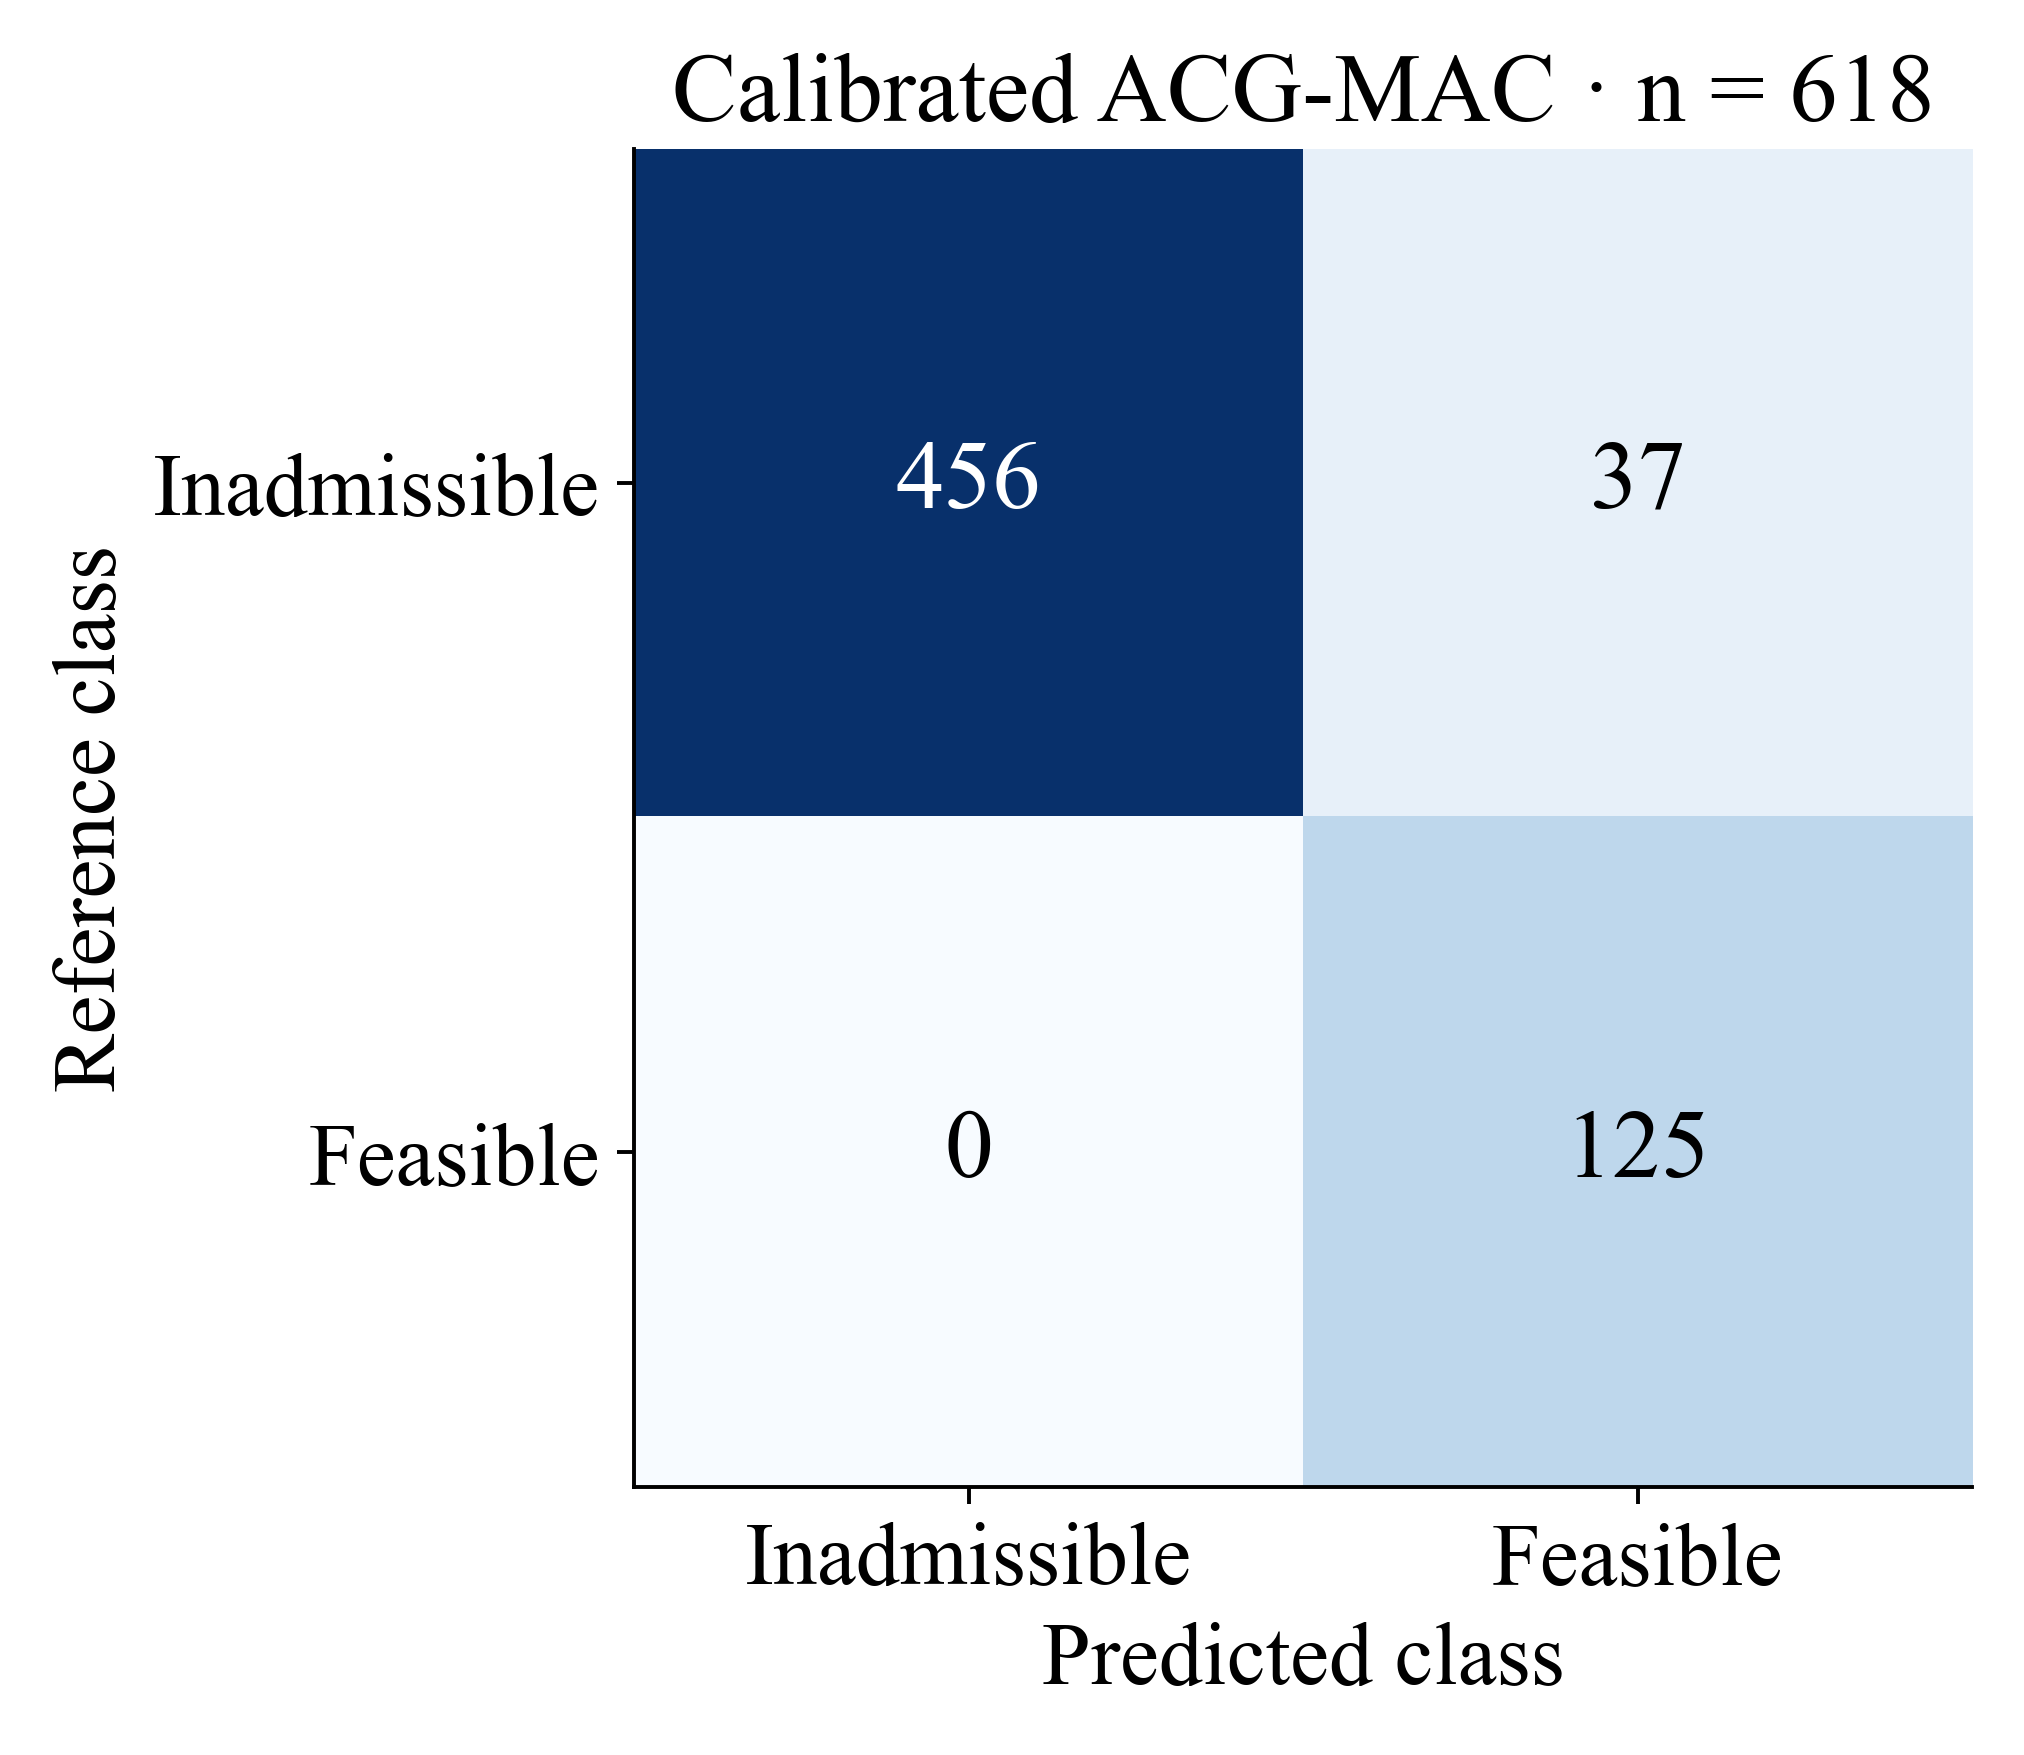

In [8]:
matrix = confusion_matrix(
    truth[selected, 2],
    calibrated_probabilities["ACG-MAC Ensemble"] >= thresholds["ACG-MAC Ensemble"],
    labels=[0, 1],
)
fig, axis = plt.subplots(figsize=(5.6, 4.8), layout="constrained")
axis.imshow(matrix, cmap="Blues")
for row in range(2):
    for column in range(2):
        axis.text(
            column,
            row,
            str(matrix[row, column]),
            ha="center",
            va="center",
            fontsize=20,
            color="white" if matrix[row, column] > matrix.max() / 2 else "black",
        )
axis.set_xticks([0, 1], ["Inadmissible", "Feasible"])
axis.set_yticks([0, 1], ["Inadmissible", "Feasible"])
axis.set(
    xlabel="Predicted class",
    ylabel="Reference class",
    title=f"Calibrated ACG-MAC · n = {len(selected)}",
)
save_figure(fig, FIGURES / "10_Calibrated_feasibility_confusion_matrix.png")
plt.show()
pd.DataFrame(
    matrix,
    index=["true_inadmissible", "true_feasible"],
    columns=["pred_inadmissible", "pred_feasible"],
).to_csv(TABLES / "06_confusion_source.csv")

False admissibility predictions remain after calibration. Candidate actions therefore require the separate numerical feasibility filter.

## Residual prediction intervals

Global and regime-stratified intervals are evaluated on withheld topologies.

In [9]:
calibration = indices["calibration"]
proxy_column = bundle.feature_names.index("proxy_vmin")
regime_edges = np.quantile(bundle.tabular[indices["train"], proxy_column], [1 / 3, 2 / 3])
calibration_regime = np.digitize(bundle.tabular[calibration, proxy_column], regime_edges)
test_regime = np.digitize(bundle.tabular[valid_test, proxy_column], regime_edges)
interval_rows, interval_store, coverage_rows = [], {}, []
for nominal in [0.5, 0.7, 0.8, 0.9, 0.95]:
    global_intervals = conformal_intervals(
        truth[calibration], prediction[calibration], prediction[valid_test], alpha=1 - nominal
    )
    stratified = [np.empty(len(valid_test)) for _ in range(4)]
    for regime in range(3):
        fit = calibration[calibration_regime == regime]
        mask = test_regime == regime
        assert len(fit) >= 25
        intervals = conformal_intervals(
            truth[fit], prediction[fit], prediction[valid_test][mask], alpha=1 - nominal
        )
        for output, values in zip(stratified, intervals):
            output[mask] = values
    for method, intervals in [
        ("Global", global_intervals),
        ("Proxy-regime stratified", stratified),
    ]:
        for target, column, lower, upper in [
            ("Vmin", 0, intervals[0], intervals[1]),
            ("Loss kW", 1, intervals[2], intervals[3]),
        ]:
            coverage = np.mean(
                (truth[valid_test, column] >= lower) & (truth[valid_test, column] <= upper)
            )
            coverage_rows.append(
                dict(method=method, target=target, nominal=nominal, coverage=coverage)
            )
            if nominal == 0.9:
                interval_rows.append(
                    dict(
                        model="ACG-MAC Ensemble",
                        split="test converged",
                        n=len(valid_test),
                        method=method,
                        target=target,
                        nominal=nominal,
                        coverage=coverage,
                        mean_width=float(np.mean(upper - lower)),
                        pinaw=float(np.mean(upper - lower) / np.ptp(truth[valid_test, column])),
                    )
                )
                interval_store[method + "_" + target + "_lower"] = lower
                interval_store[method + "_" + target + "_upper"] = upper
interval_results = pd.DataFrame(interval_rows)
interval_results.to_csv(RESULTS / "uncertainty.csv", index=False)
pd.DataFrame(coverage_rows).to_csv(TABLES / "06_coverage_source.csv", index=False)
np.savez_compressed(RESULTS / "intervals.npz", **interval_store)
show_table(
    interval_results,
    ["model", "split", "n", "method", "target"],
    {"Interval performance": ["nominal", "coverage", "mean_width", "pinaw"]},
    TABLES / "06_uncertainty.csv",
    digits=6,
)

model,split,n,method,target,nominal,coverage,mean_width,pinaw
ACG-MAC Ensemble,test converged,605,Global,Vmin,0.900000,0.833058,0.005399,0.010892
ACG-MAC Ensemble,test converged,605,Global,Loss kW,0.900000,0.884298,22.937294,0.011613
ACG-MAC Ensemble,test converged,605,Proxy-regime stratified,Vmin,0.900000,0.864463,0.006108,0.012323
ACG-MAC Ensemble,test converged,605,Proxy-regime stratified,Loss kW,0.900000,0.910744,31.282303,0.015838


Coverage is empirical under topology shift. Stratification uses only training proxy thresholds and calibration residuals. Neither method is guaranteed to attain nominal coverage when calibration and test topologies differ.

## Coverage across nominal levels

Observed coverage is compared with nominal coverage across interval levels.

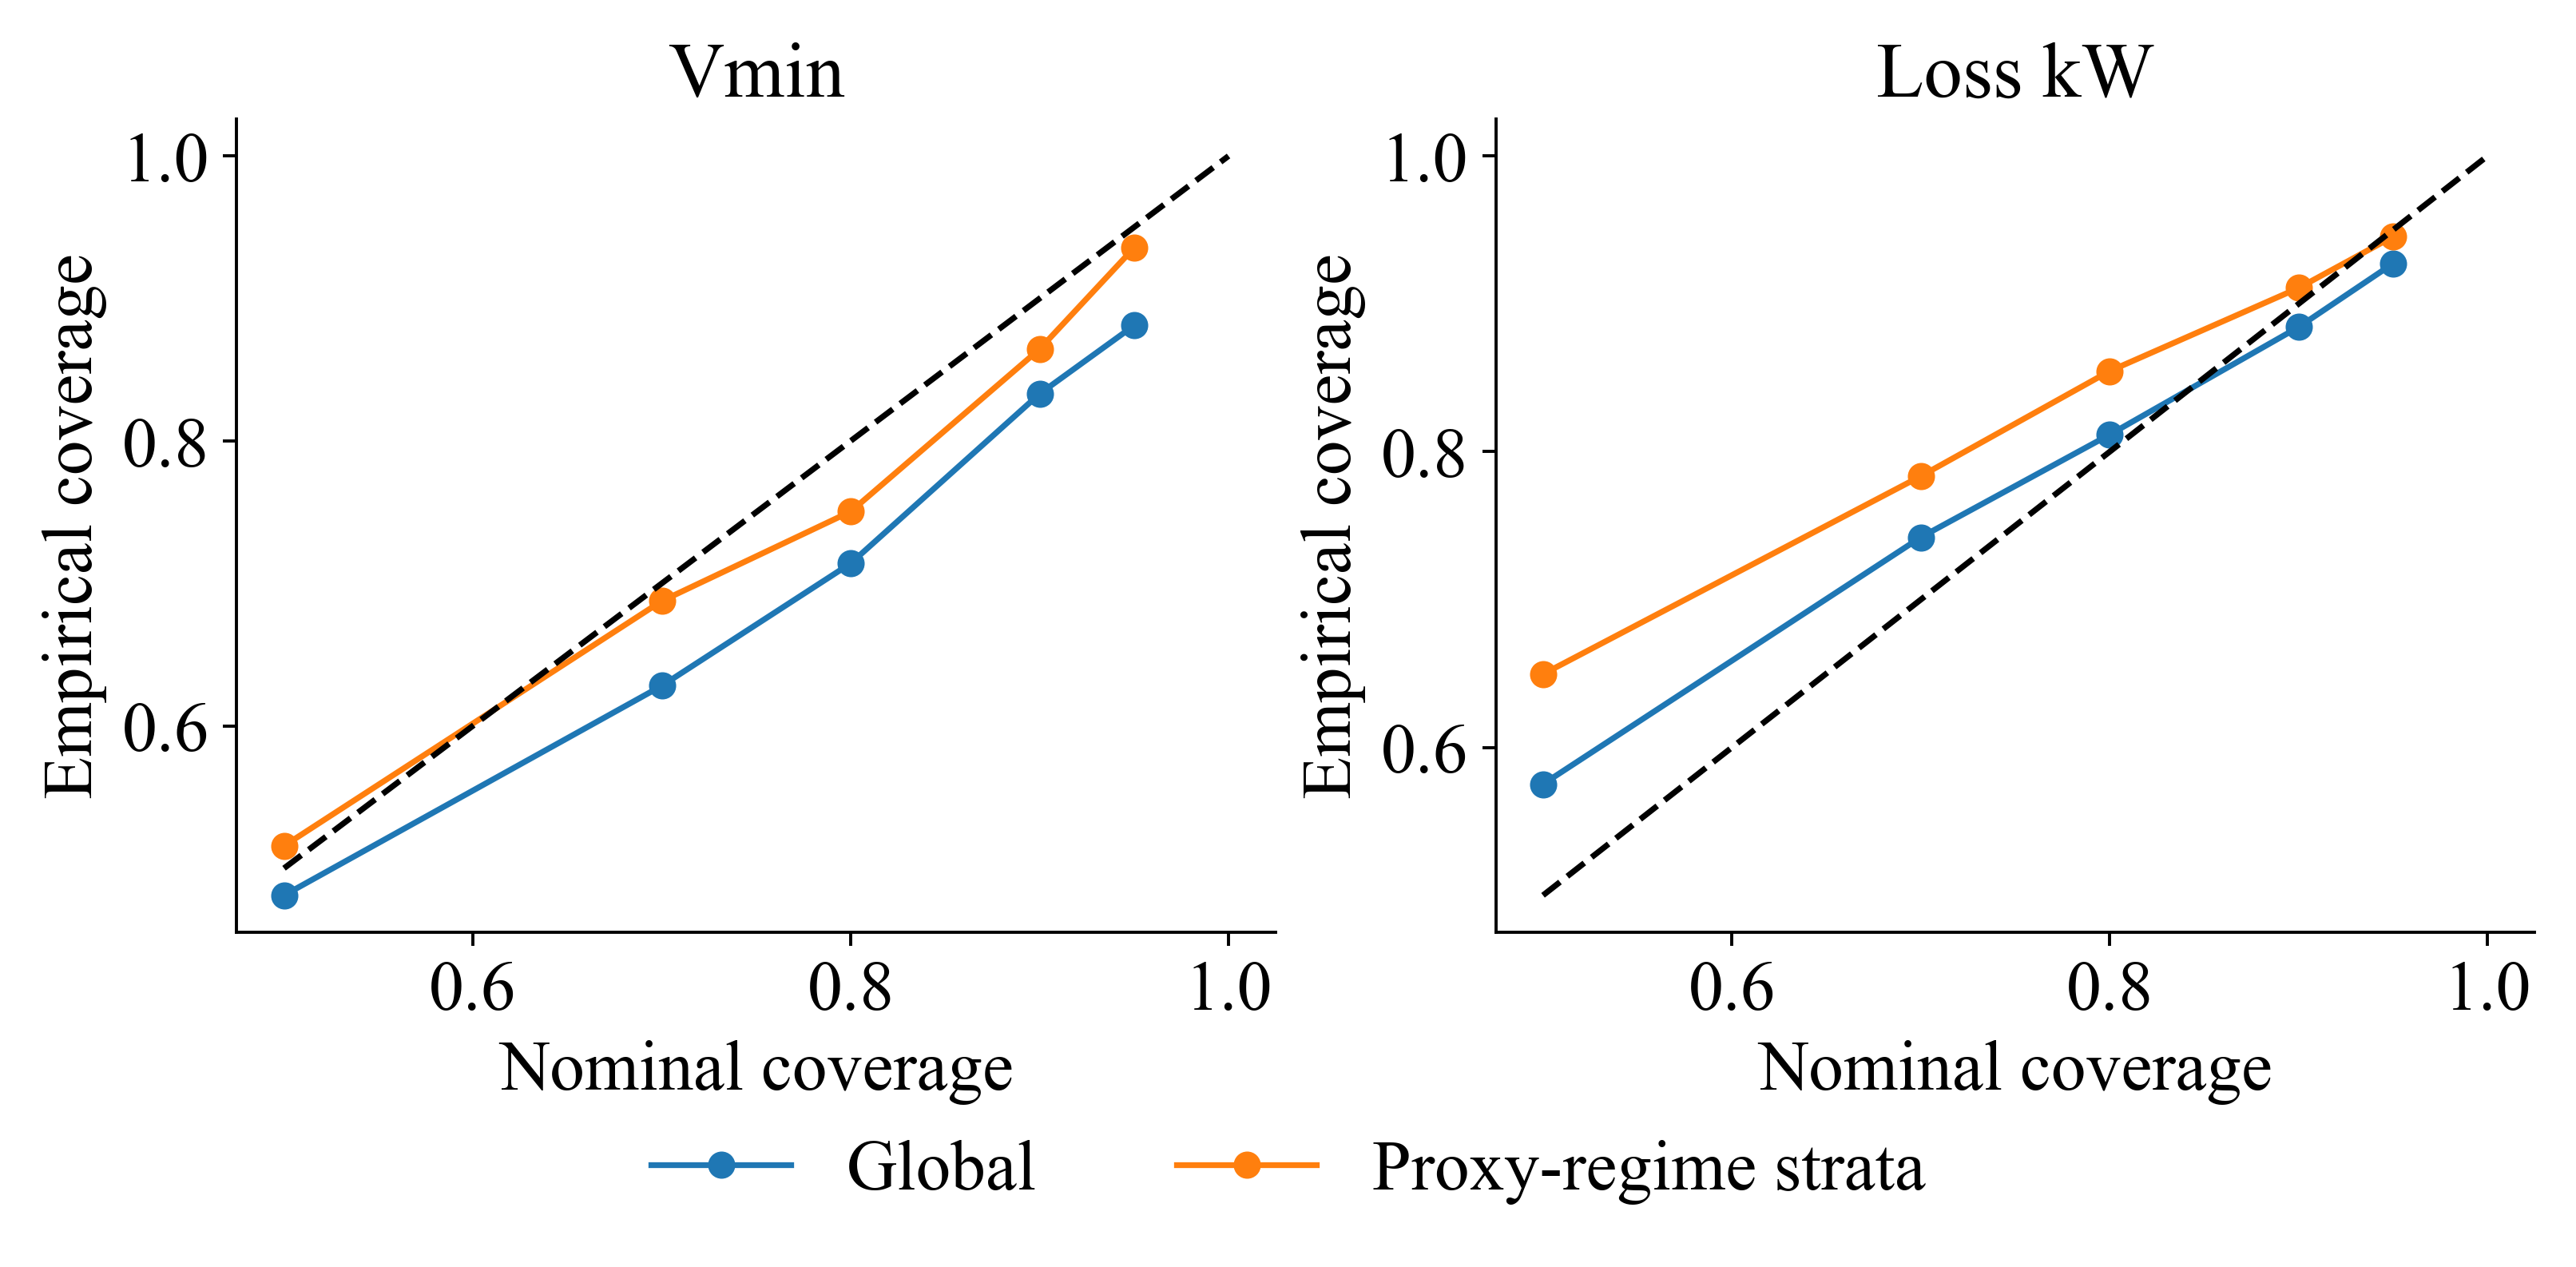

In [10]:
coverage = pd.DataFrame(coverage_rows)
fig, axes = plt.subplots(1, 2, figsize=(9.0, 4.4), layout="constrained")
for axis, target in zip(axes, ["Vmin", "Loss kW"]):
    for method, group in coverage[coverage.target.eq(target)].groupby("method", sort=False):
        axis.plot(
            group.nominal,
            group.coverage,
            marker="o",
            label=method.replace("Proxy-regime stratified", "Proxy-regime strata"),
        )
    axis.plot([0.5, 1], [0.5, 1], "k--")
    axis.set(xlabel="Nominal coverage", ylabel="Empirical coverage", title=target)
legend_handles, legend_labels = axes[1].get_legend_handles_labels()
fig.legend(legend_handles, legend_labels, loc="outside lower center", ncol=2, frameon=False)
save_figure(fig, FIGURES / "11_Prediction_interval_coverage.png")
plt.show()

The diagonal denotes nominal coverage. Deviations show the limits of residual calibration for previously unseen topologies; they cannot be repaired by selecting a nominal level on the test set.

## Topology and stress subgroups

Errors are decomposed by electrical topology and training-derived load regimes.

In [11]:
subgroup_rows = []
test_metadata = metadata.iloc[valid_test].copy()
load_bins = np.quantile(metadata.iloc[indices["train"]].global_scale, [0.25, 0.5, 0.75])
test_metadata["load_regime"] = np.digitize(test_metadata.global_scale, load_bins)
for factor in ["topology_id", "load_regime"]:
    for group, frame in test_metadata.groupby(factor):
        rows = frame.index.to_numpy()
        metrics = regression_metrics(truth[rows], prediction[rows])
        subgroup_rows.append(
            dict(
                model="ACG-MAC Ensemble",
                split="test converged",
                factor=factor,
                group=str(group),
                n=len(rows),
                vmin_mae=metrics["vmin_mae"],
                loss_mae_kw=metrics["loss_mae_kw"],
            )
        )
subgroups = pd.DataFrame(subgroup_rows)
subgroups.to_csv(RESULTS / "subgroups.csv", index=False)
show_table(
    subgroups,
    ["model", "split", "factor", "group", "n"],
    {"Subgroup absolute errors ↓": ["vmin_mae", "loss_mae_kw"]},
    TABLES / "06_subgroups.csv",
    digits=6,
)

model,split,factor,group,n,vmin_mae,loss_mae_kw
ACG-MAC Ensemble,test converged,topology_id,5,55,0.012704,94.779711
ACG-MAC Ensemble,test converged,topology_id,16,69,0.001002,4.249626
ACG-MAC Ensemble,test converged,topology_id,17,78,0.001361,2.626388
ACG-MAC Ensemble,test converged,topology_id,19,76,0.000946,2.569709
ACG-MAC Ensemble,test converged,topology_id,22,62,0.000745,2.142162
ACG-MAC Ensemble,test converged,topology_id,25,58,0.002030,6.418994
ACG-MAC Ensemble,test converged,topology_id,39,64,0.001333,5.199546
ACG-MAC Ensemble,test converged,topology_id,52,82,0.002606,8.389051
ACG-MAC Ensemble,test converged,topology_id,58,61,0.000760,2.730062
ACG-MAC Ensemble,test converged,load_regime,0,153,0.001274,3.178262


Subgroups are defined by topology and training-derived load thresholds. Worst-group errors must accompany averages; small subgroup sizes limit precision.

## Seed and fold stability

Seed repeats and topology folds describe different sources of variability.

In [12]:
seed_results = pd.concat(
    [
        pd.read_csv(RESULTS / filename)
        for filename in ["baseline_seeds.csv", "graph_seeds.csv", "acg_seeds.csv"]
    ],
    ignore_index=True,
)
stability = (
    seed_results.groupby(["model", "split", "n"], sort=False)
    .agg(
        seeds=("seed", "nunique"),
        vmin_rmse_mean=("vmin_rmse", "mean"),
        vmin_rmse_sd=("vmin_rmse", "std"),
        loss_rmse_mean_kw=("loss_rmse_kw", "mean"),
        loss_rmse_sd_kw=("loss_rmse_kw", "std"),
    )
    .reset_index()
)
stability.to_csv(RESULTS / "seed_summary.csv", index=False)
show_table(
    stability,
    ["model", "split", "n"],
    {
        "Initialization variation": [
            "seeds",
            "vmin_rmse_mean",
            "vmin_rmse_sd",
            "loss_rmse_mean_kw",
            "loss_rmse_sd_kw",
        ]
    },
    TABLES / "06_seed_stability.csv",
    digits=6,
)

model,split,n,seeds,vmin_rmse_mean,vmin_rmse_sd,loss_rmse_mean_kw,loss_rmse_sd_kw
LinearDistFlow,test converged,605,1,0.020858,Not applicable,132.268467,Not applicable
Ridge,test converged,605,3,0.009549,0.000000,47.494253,0.000000
RandomForest,test converged,605,3,0.013227,0.000449,89.200483,1.474425
ExtraTrees,test converged,605,3,0.018372,0.000633,124.403224,2.197269
MLP,test converged,605,3,0.011474,0.001312,29.668188,7.678919
XGBoost,test converged,605,3,0.016774,0.000747,82.928297,4.577306
LightGBM,test converged,605,3,0.016685,0.000213,105.267016,2.562746
GCN Direct,test converged,605,3,0.021165,0.002485,91.260957,28.308842
Physics-Residual GCN,test converged,605,3,0.007904,0.000964,41.963934,14.271945
ACG-MAC Full,test converged,605,5,0.007406,0.000838,49.236653,11.245148


ACG-MAC rows here describe single members, not five independent ensembles. Linear DistFlow has no initialization variability; its single-run standard deviation is not applicable. OOF variability separately measures withheld-topology effects.

## Paired telemetry stress experiment

Fixed operating states receive jointly increasing missingness, noise and telemetry age.

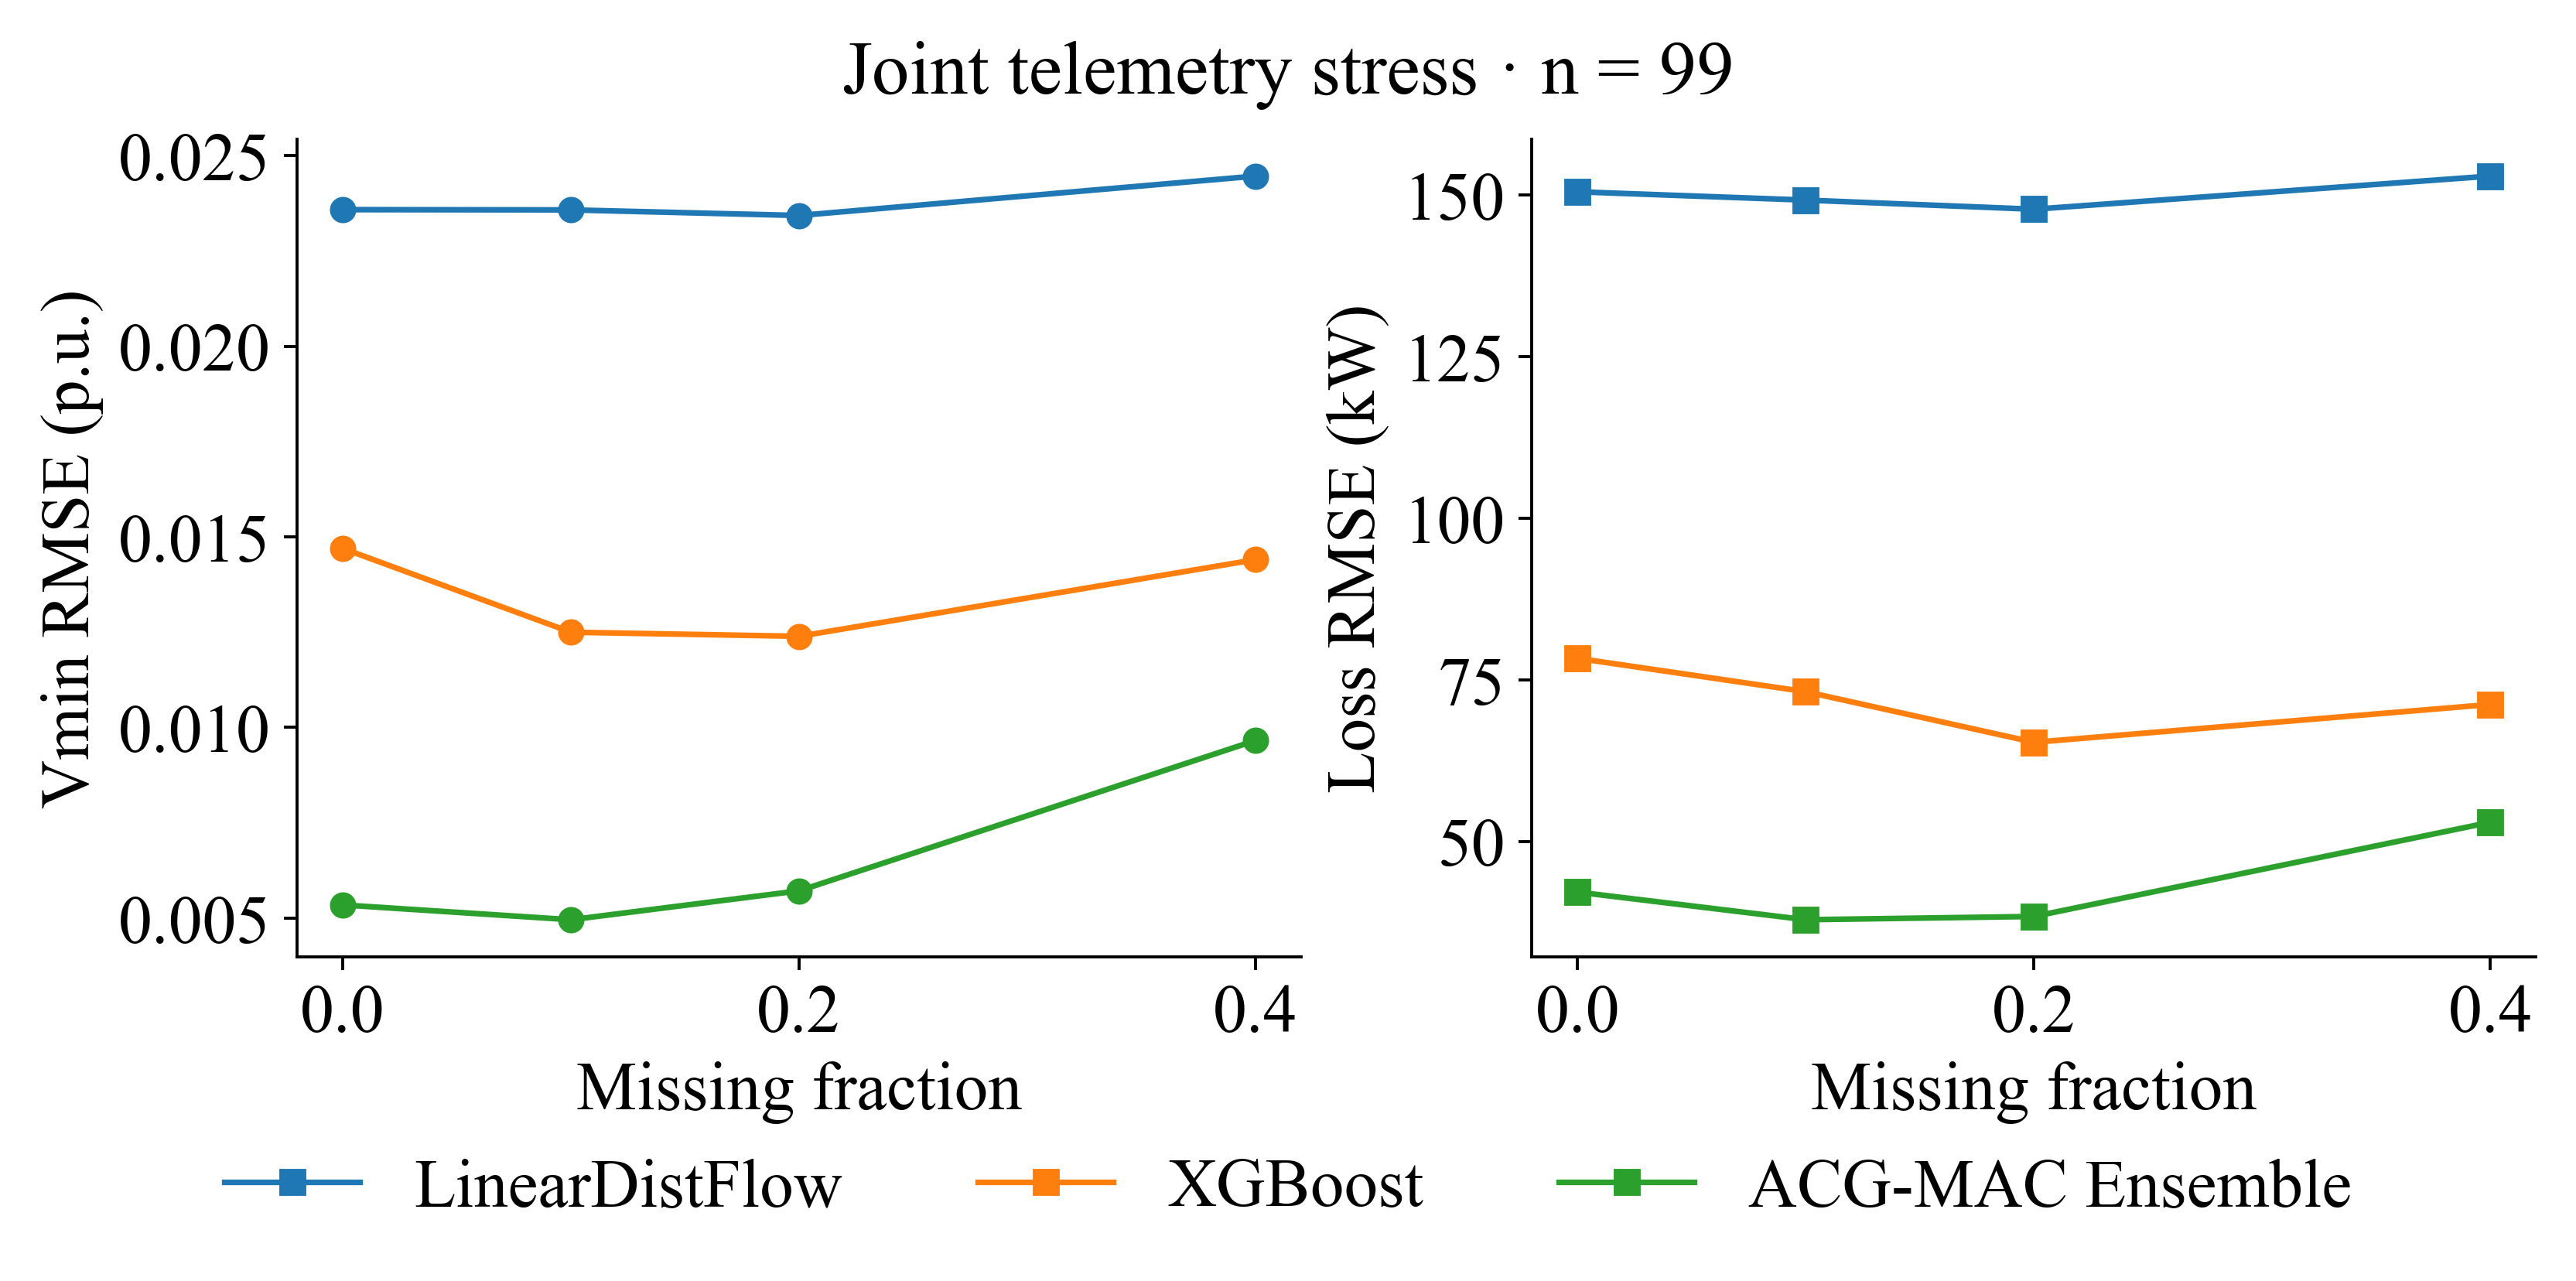

In [13]:
benchmark = case33()
topologies = enumerate_case33_topologies()
test_topologies = [
    topology
    for topology in topologies
    if topology.topology_id in set(metadata.iloc[indices["test"]].topology_id)
]
stress_rng = np.random.default_rng(SEED + 100)
states = []
for state_number in range(100):
    topology = test_topologies[state_number % len(test_topologies)]
    active, reactive, _ = generate_load_state(benchmark, stress_rng)
    source_voltage = float(stress_rng.uniform(0.99, 1.05))
    exact = radial_power_flow(benchmark, active, reactive, topology, source_voltage)
    if exact["converged"]:
        states.append((topology, active, reactive, source_voltage))
stress_rows = []
for missing_fraction, noise_scale, age_value in [
    (0.0, 0.0, 0.0),
    (0.1, 0.01, 0.5),
    (0.2, 0.02, 1.0),
    (0.4, 0.04, 2.0),
]:
    nodes, adjacencies, masks, tabs, targets = [], [], [], [], []
    perturbation_rng = np.random.default_rng(SEED + 101)
    for topology, active, reactive, source_voltage in states:
        observed = (perturbation_rng.random(33) >= missing_fraction).astype(float)
        observed[0] = 1.0
        active_observed = active * (1 + perturbation_rng.normal(0, noise_scale, 33))
        reactive_observed = reactive * (1 + perturbation_rng.normal(0, noise_scale, 33))
        active_observed[observed == 0] = np.nan
        reactive_observed[observed == 0] = np.nan
        ages = np.full(33, age_value)
        candidate, exact = build_candidate_bundle(
            bundle,
            active,
            reactive,
            active_observed,
            reactive_observed,
            observed,
            ages,
            [(topology, source_voltage)],
        )
        nodes.append(candidate.node_features[0])
        adjacencies.append(candidate.adjacency[0])
        masks.append(candidate.node_mask[0])
        tabs.append(candidate.tabular[0])
        targets.append(candidate.targets[0])
    stressed = DatasetBundle(
        pd.DataFrame({"split": ["test"] * len(states)}),
        np.stack(nodes),
        np.stack(adjacencies),
        np.stack(masks),
        np.stack(tabs),
        np.stack(targets),
        bundle.feature_names,
    )
    for name in ["LinearDistFlow", "XGBoost", "ACG-MAC Ensemble"]:
        if name == "ACG-MAC Ensemble":
            stressed_prediction, _ = ensemble_predict(stressed, np.arange(len(states)))
        else:
            estimators = (
                None if name == "LinearDistFlow" else joblib.load(MODELS / (name + ".joblib"))
            )
            stressed_prediction, _ = predict_tabular(
                estimators, stressed, np.arange(len(states))
            )
        metrics = regression_metrics(stressed.targets, stressed_prediction)
        stress_rows.append(
            dict(
                model=name,
                split="paired telemetry stress",
                n=len(states),
                missing_fraction=missing_fraction,
                noise_sd=noise_scale,
                age=age_value,
                **metrics,
            )
        )
stress = pd.DataFrame(stress_rows)
stress.to_csv(RESULTS / "telemetry_stress.csv", index=False)
fig, axes = plt.subplots(1, 2, figsize=(9.3, 4.6), layout="constrained")
for name, group in stress.groupby("model", sort=False):
    axes[0].plot(group.missing_fraction, group.vmin_rmse, marker="o", label=name)
    axes[1].plot(group.missing_fraction, group.loss_rmse_kw, marker="s", label=name)
axes[0].set(xlabel="Missing fraction", ylabel="Vmin RMSE (p.u.)")
axes[1].set(xlabel="Missing fraction", ylabel="Loss RMSE (kW)")
legend_handles, legend_labels = axes[1].get_legend_handles_labels()
fig.legend(legend_handles, legend_labels, loc="outside lower center", ncol=3, frameon=False)
fig.suptitle("Joint telemetry stress · n = " + str(int(stress.n.iloc[0])), fontsize=20)
save_figure(fig, FIGURES / "12_Telemetry_degradation_errors.png")
plt.show()

The 99 true operating states and targets are fixed across perturbations. Missingness, noise and age increase jointly, so this is a combined stress test rather than identification of their separate causal effects.

## Conditional channel importance

Within-topology permutations measure reliance on groups of input channels.

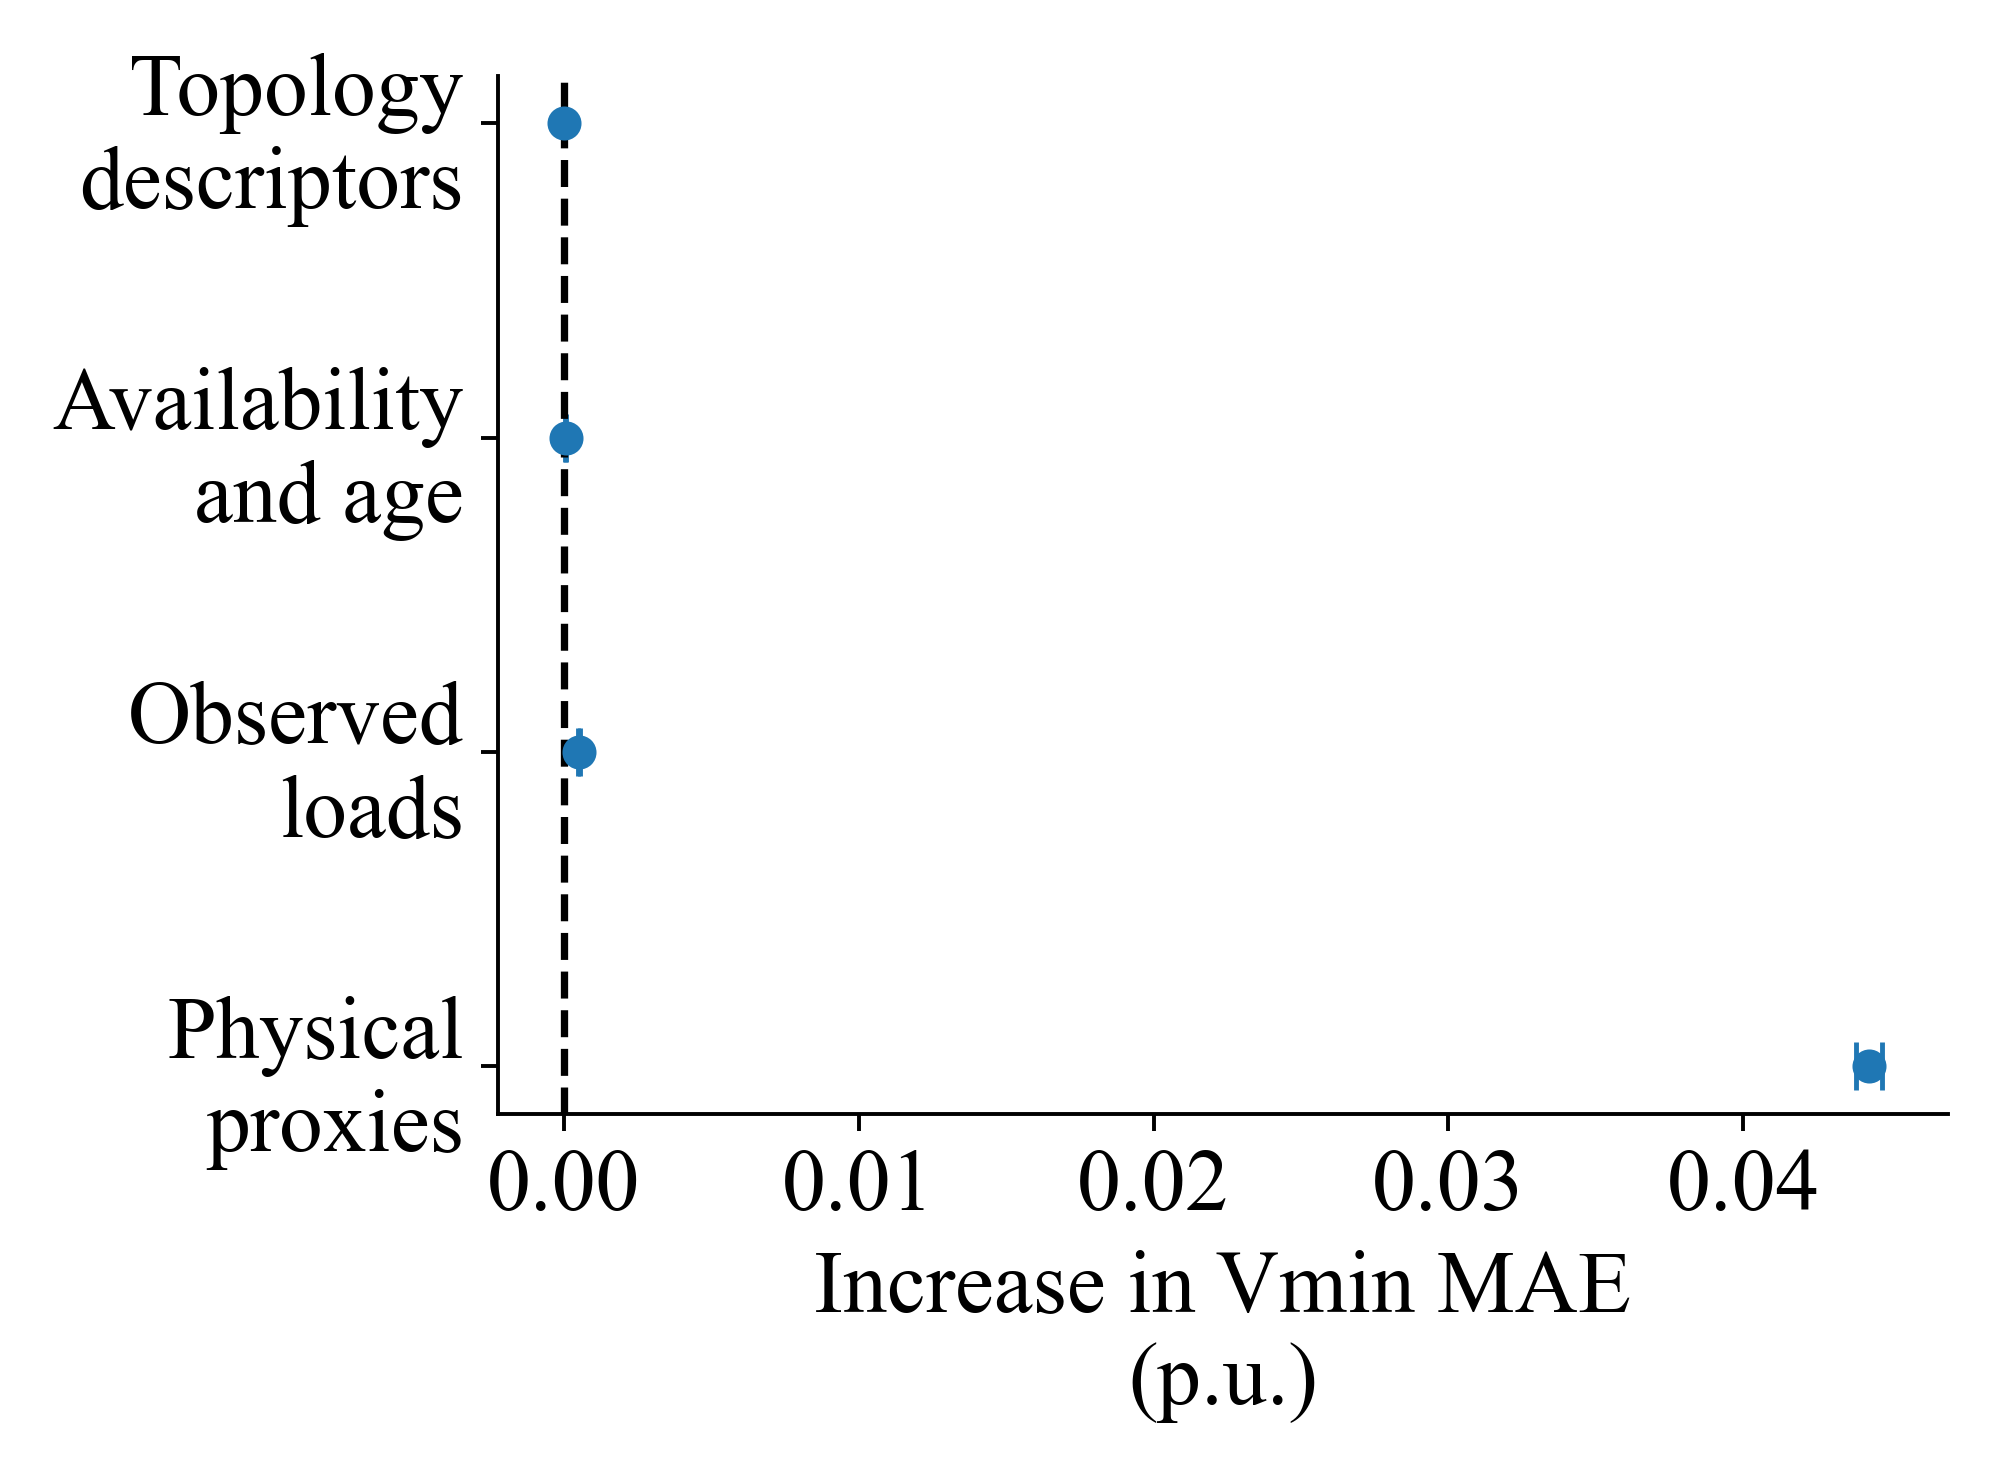

In [14]:
importance_rng = np.random.default_rng(SEED + 102)
base_voltage = np.mean(np.abs(truth[valid_test, 0] - prediction[valid_test, 0]))
feature_blocks = {
    "Physical proxies": ([], ["proxy_vmin", "proxy_loss_kw"]),
    "Observed load channels": (
        [0, 1],
        [
            "total_p_kw",
            "total_q_kvar",
            "mean_p_kw",
            "std_p_kw",
            "max_p_kw",
            "mean_q_kvar",
            "std_q_kvar",
        ],
    ),
    "Availability and age": ([6, 7], ["missing_rate", "mean_age", "max_age"]),
    "Topology descriptors": (
        [],
        [
            "n_bus",
            "depth_max",
            "depth_mean",
            "degree_mean",
            "degree_max",
            "r_sum",
            "x_sum",
            "z_max",
        ],
    ),
}
blocks = {
    name: (node_columns, [bundle.feature_names.index(feature) for feature in features])
    for name, (node_columns, features) in feature_blocks.items()
}
importance_rows = []
for block, (node_columns, tab_columns) in blocks.items():
    for repeat in range(5):
        node_values = bundle.node_features.copy()
        tab_values = bundle.tabular.copy()
        for topology in np.unique(test_groups):
            rows = valid_test[test_groups == topology]
            donors = importance_rng.permutation(rows)
            for column in node_columns:
                node_values[rows, :, column] = bundle.node_features[donors, :, column]
            for column in tab_columns:
                tab_values[rows, column] = bundle.tabular[donors, column]
        perturbed = replace(bundle, node_features=node_values, tabular=tab_values)
        perturbed_prediction, _ = ensemble_predict(perturbed, valid_test)
        importance_rows.append(
            dict(
                block=block,
                repeat=repeat,
                delta_vmin_mae=float(
                    np.mean(np.abs(truth[valid_test, 0] - perturbed_prediction[:, 0]))
                    - base_voltage
                ),
            )
        )
importance = pd.DataFrame(importance_rows)
grouped = (
    importance.groupby("block", sort=False).delta_vmin_mae.agg(["mean", "std"]).reset_index()
)
fig, axis = plt.subplots(figsize=(5.5, 4.0), layout="constrained")
axis.errorbar(grouped["mean"], np.arange(len(grouped)), xerr=grouped["std"], fmt="o", capsize=5)
axis.axvline(0, color="black", linestyle="--")
labels = grouped.block.replace(
    {
        "Physical proxies": "Physical\nproxies",
        "Observed load channels": "Observed\nloads",
        "Availability and age": "Availability\nand age",
        "Topology descriptors": "Topology\ndescriptors",
    }
)
axis.set_yticks(np.arange(len(grouped)), labels)
axis.set(xlabel="Increase in Vmin MAE\n(p.u.)", ylabel="")
save_figure(fig, FIGURES / "13_Conditional_feature_group_reliance.png")
plt.show()
importance.to_csv(TABLES / "06_importance_source.csv", index=False)

Permutations stay within each topology and assess conditional model reliance, not causal effects. Correlated proxy/node channels can produce inconsistent synthetic combinations. Topology descriptors are constant within topology, so their near-zero permutation effect is not evidence of irrelevance.

## Representative error cases

Best, median and worst voltage errors are compared with ensemble spread.

In [15]:
saved = np.load(prediction_path("ACG-MAC Ensemble"))
member_spread = saved["members"][:, valid_test, 0].std(axis=0)
error = np.abs(truth[valid_test, 0] - prediction[valid_test, 0])
ordering = np.argsort(error)
positions = np.unique(
    np.r_[ordering[:2], ordering[len(ordering) // 2 : len(ordering) // 2 + 2], ordering[-2:]]
)
case_rows = []
for position in positions:
    row = valid_test[position]
    case_rows.append(
        dict(
            sample_id=int(metadata.iloc[row].sample_id),
            split="test converged",
            n=1,
            topology=int(metadata.iloc[row].topology_id),
            true_vmin=float(truth[row, 0]),
            predicted_vmin=float(prediction[row, 0]),
            absolute_error=float(error[position]),
            ensemble_sd=float(member_spread[position]),
            missing_fraction=float(metadata.iloc[row].missing_rate),
        )
    )
cases = pd.DataFrame(case_rows).sort_values("absolute_error")
show_table(
    cases,
    ["sample_id", "split", "n", "topology"],
    {
        "Local prediction": ["true_vmin", "predicted_vmin", "absolute_error"],
        "Confidence and telemetry": ["ensemble_sd", "missing_fraction"],
    },
    TABLES / "06_cases.csv",
    digits=6,
)
association = spearmanr(member_spread, error).statistic

Between-member voltage spread is positively associated with absolute error, but does not isolate aleatoric uncertainty. Best, median and worst examples describe error cases rather than their population frequencies.

## Error regimes and low confidence

Voltage errors are related to the true target, predictions and member disagreement.

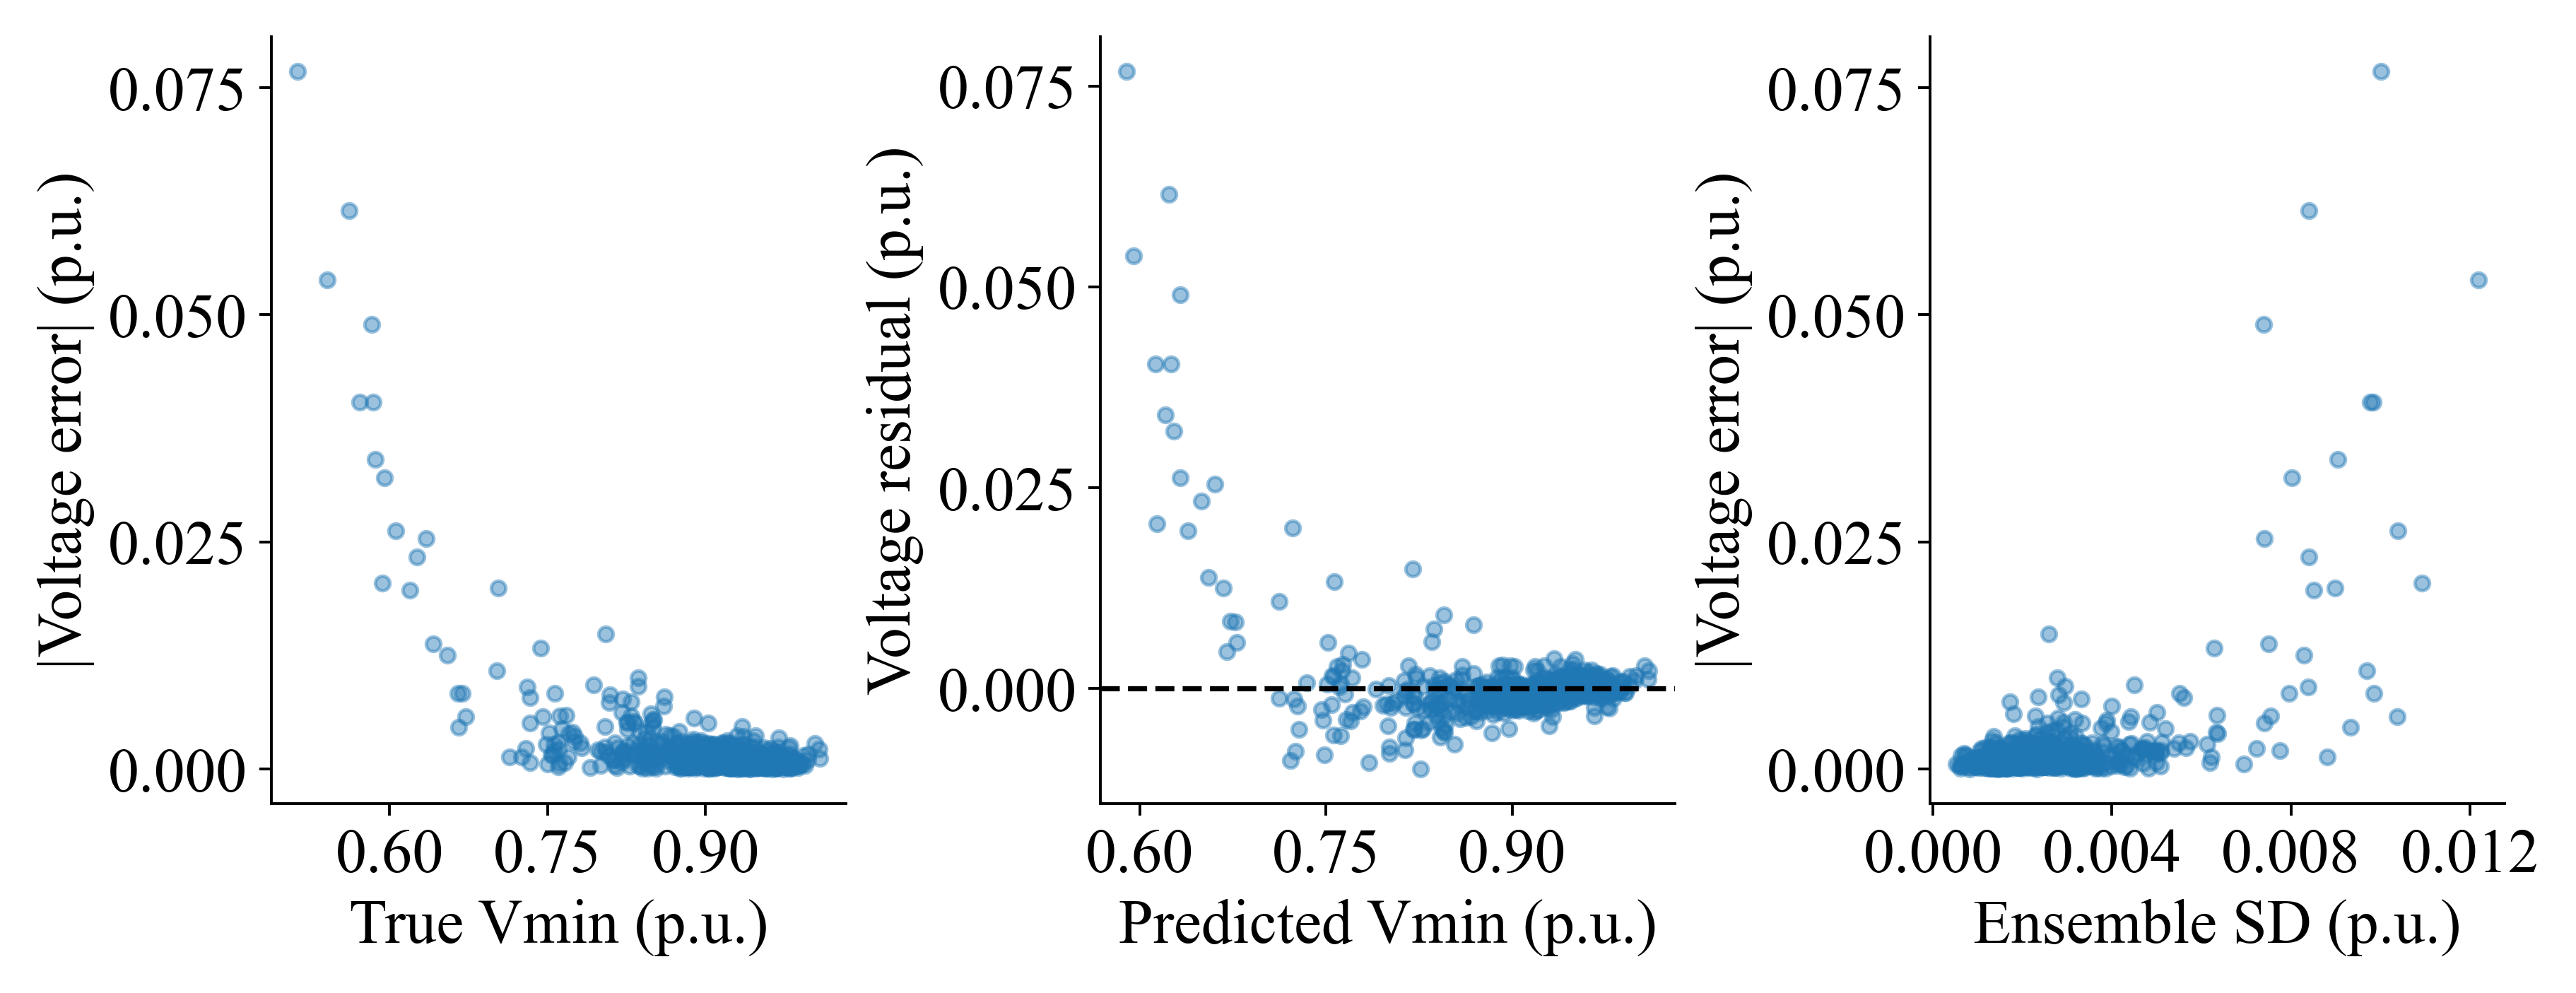

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(10.2, 3.8), layout="constrained")
axes[0].scatter(truth[valid_test, 0], error, s=18, alpha=0.45)
axes[1].scatter(
    prediction[valid_test, 0],
    prediction[valid_test, 0] - truth[valid_test, 0],
    s=18,
    alpha=0.45,
)
axes[1].axhline(0, color="black", linestyle="--")
axes[2].scatter(member_spread, error, s=18, alpha=0.45)
axes[0].set(xlabel="True Vmin (p.u.)", ylabel="|Voltage error| (p.u.)")
axes[1].set(xlabel="Predicted Vmin (p.u.)", ylabel="Voltage residual (p.u.)")
axes[2].set(xlabel="Ensemble SD (p.u.)", ylabel="|Voltage error| (p.u.)")
from matplotlib.ticker import MaxNLocator

for panel in axes:
    panel.xaxis.set_major_locator(MaxNLocator(nbins=4))
    panel.yaxis.set_major_locator(MaxNLocator(nbins=4))
save_figure(fig, FIGURES / "14_Error_regimes_and_ensemble_disagreement.png")
plt.show()
pd.DataFrame(
    dict(
        sample_id=valid_test,
        true_vmin=truth[valid_test, 0],
        predicted_vmin=prediction[valid_test, 0],
        absolute_error=error,
        member_sd=member_spread,
    )
).to_csv(TABLES / "06_error_regimes_source.csv", index=False)

The plots diagnose systematic bias and low-confidence failures. Time-dependent errors are not analyzed because the study contains independently sampled states rather than sequential measurements.

## Local external-network supervision

Limited local fitting and calibration use disjoint labels from the external test.

In [17]:
from sklearn.model_selection import train_test_split

external = indices["external"]
local, external_test = train_test_split(
    external, train_size=80, random_state=SEED + 103, stratify=truth[external, 2]
)
local_fit, local_calibration = train_test_split(
    local, train_size=64, random_state=SEED + 104, stratify=truth[local, 2]
)
assert not set(local) & set(external_test)
adapted = train_graph(
    bundle,
    np.r_[indices["train"], local_fit],
    indices["selection"],
    FULL_CONFIG,
    seed=SEED + 105,
    **TRAINING
)
save_graph(adapted, MODELS / "ACG_MAC_local.pt", bundle)
local_prediction, local_probability, _ = predict_graph_model(adapted, bundle, local_calibration)
external_prediction, external_probability, _ = predict_graph_model(
    adapted, bundle, external_test
)
corrections = []
corrected = external_prediction.copy()
for column, alpha in [(0, 0.001), (1, 0.1)]:
    calibration_feature = (
        local_prediction[:, column] if column == 0 else np.log1p(local_prediction[:, column])
    )
    test_feature = (
        external_prediction[:, column]
        if column == 0
        else np.log1p(external_prediction[:, column])
    )
    target = (
        truth[local_calibration, column]
        if column == 0
        else np.log1p(truth[local_calibration, column])
    )
    correction = Ridge(alpha=alpha).fit(calibration_feature.reshape(-1, 1), target)
    corrected[:, column] = correction.predict(test_feature.reshape(-1, 1))
    if column == 1:
        corrected[:, column] = np.maximum(0, np.expm1(corrected[:, column]))
    corrections.append(correction)
external_calibrated, external_threshold, external_mapper = calibrate_probability(
    truth[local_calibration, 2], local_probability, external_probability
)
joblib.dump(
    dict(regression=corrections, probability=external_mapper, threshold=external_threshold),
    MODELS / "ACG_MAC_local_calibration.joblib",
)
external_rows = []
for method, values, probabilities in [
    ("Zero-shot ensemble", prediction[external_test], probability[external_test]),
    ("64 fit + 16 calibration", corrected, external_calibrated),
]:
    external_rows.append(
        dict(
            model=method,
            split="same external test",
            n=len(external_test),
            local_fit_n=0 if method.startswith("Zero") else len(local_fit),
            local_calibration_n=0 if method.startswith("Zero") else len(local_calibration),
            **regression_metrics(truth[external_test], values)
        )
    )
transfer = pd.DataFrame(external_rows)
transfer.to_csv(RESULTS / "external_transfer.csv", index=False)
pd.DataFrame(
    dict(
        sample_id=external,
        role=[
            (
                "fit"
                if row in local_fit
                else "local calibration" if row in local_calibration else "external test"
            )
            for row in external
        ],
    )
).to_csv(RESULTS / "external_roles.csv", index=False)
np.savez_compressed(
    RESULTS / "external_adaptation_predictions.npz",
    sample_id=external_test,
    prediction=corrected,
    probability=external_calibrated,
)
show_table(
    transfer,
    ["model", "split", "n"],
    {
        "Local supervision": ["local_fit_n", "local_calibration_n"],
        "Voltage (errors ↓, R² ↑)": ["vmin_rmse", "vmin_mae", "vmin_r2"],
        "Losses (errors ↓, R² ↑)": ["loss_rmse_kw", "loss_mae_kw", "loss_r2"],
    },
    TABLES / "06_external.csv",
    digits=6,
)

Eighty external labels are partitioned into 64 fit and 16 independent calibration states; the same 720 states score both methods. This is local supervised adaptation plus output calibration, not zero-shot transfer or a pure calibration-only update. The small local calibration set limits certainty.

## External input support

External structural features are compared with the feature ranges used for training.

In [18]:
support_rows = []
for feature in ["n_bus", "depth_max", "depth_mean", "degree_mean", "r_sum", "x_sum", "z_max"]:
    column = bundle.feature_names.index(feature)
    train_values = bundle.tabular[indices["train"], column]
    external_values = bundle.tabular[indices["external"], column]
    normalized_external = (external_values - members[0].tab_mean[column]) / members[0].tab_std[
        column
    ]
    support_rows.append(
        dict(
            feature=feature,
            split="external vs train",
            n=len(external_values),
            train_min=float(train_values.min()),
            train_max=float(train_values.max()),
            constant_in_train=bool(np.ptp(train_values) == 0),
            external_min=float(external_values.min()),
            external_max=float(external_values.max()),
            max_abs_standardized_external=float(np.abs(normalized_external).max()),
        )
    )
support = pd.DataFrame(support_rows)
show_table(
    support,
    ["feature", "split", "n"],
    {
        "Training support": ["train_min", "train_max", "constant_in_train"],
        "External extrapolation": [
            "external_min",
            "external_max",
            "max_abs_standardized_external",
        ],
    },
    TABLES / "06_external_support.csv",
    digits=6,
)

feature,split,n,train_min,train_max,constant_in_train
n_bus,external vs train,800,33.000000,33.000000,True
depth_max,external vs train,800,13.000000,25.000000,False
depth_mean,external vs train,800,6.545455,10.636364,False
degree_mean,external vs train,800,1.939394,1.939394,True
r_sum,external vs train,800,19.789400,22.381800,False
x_sum,external vs train,800,16.563299,19.719299,False
z_max,external vs train,800,2.024778,2.828427,False
feature,split,n,external_min,external_max,max_abs_standardized_external
n_bus,external vs train,800,69.000000,69.000000,36.000000
depth_max,external vs train,800,26.000000,26.000000,2.145341


Training includes 33-bus networks only. Standard deviations below 1e−6 are replaced with one during scaling. The external n_bus shift is 36 standardized units; a small floating-point scale for degree_mean produces a shift of about 716 units. These features characterize extrapolation associated with zero-shot error, without isolating its causal contribution.

## Numerical failures as a separate regime

Classification confidence is examined for numerically unresolved states.

In [19]:
failed = indices["test"][metadata.iloc[indices["test"]].converged.to_numpy() == 0]
failed_positions = np.flatnonzero(metadata.iloc[indices["test"]].converged.to_numpy() == 0)
failed_probabilities = calibrated_probabilities["ACG-MAC Ensemble"][failed_positions]
failure_summary = pd.DataFrame(
    [
        dict(
            model="ACG-MAC Ensemble",
            split="nonconverged test",
            n=len(failed),
            mean_feasibility_probability=float(failed_probabilities.mean()),
            predicted_feasible_n=int(
                (failed_probabilities >= thresholds["ACG-MAC Ensemble"]).sum()
            ),
            regression_evaluation="excluded: no converged reference",
        )
    ]
)
show_table(
    failure_summary,
    ["model", "split", "n"],
    {
        "Failure-mode behavior": [
            "mean_feasibility_probability",
            "predicted_feasible_n",
            "regression_evaluation",
        ]
    },
    TABLES / "06_failures.csv",
    digits=6,
)

model,split,n,mean_feasibility_probability,predicted_feasible_n,regression_evaluation
ACG-MAC Ensemble,nonconverged test,13,0.000117,0,excluded: no converged reference


Numerically unresolved labels are conservatively inadmissible; this does not establish mathematical infeasibility. Their finite last-iterate voltages and losses are never used as regression ground truth.

## Action ranking with exact rejection

Candidate ranking is followed by numerical convergence and voltage checks, with abstention when no candidate passes.

In [20]:
decision_rng = np.random.default_rng(SEED + 106)
base_edges = set(np.flatnonzero(CASE33_EDGE_DATA[:, 4] == 1).tolist())
fault_options = sorted(
    {edge for topology in test_topologies for edge in base_edges - set(topology.edge_indices)}
)
assert fault_options
decision_rows = []
estimators = joblib.load(MODELS / "ExtraTrees.joblib")
for episode in range(120):
    active, reactive, _ = generate_load_state(benchmark, decision_rng)
    active_observed, reactive_observed, observed, ages = corrupt_telemetry(
        active, reactive, decision_rng, max_missing=0.25
    )
    fault = int(decision_rng.choice(fault_options)) if episode >= 60 else -1
    available = [
        topology
        for topology in test_topologies
        if fault < 0 or fault not in topology.edge_indices
    ]
    assert available
    candidates = [
        (topology, source_voltage)
        for topology in available
        for source_voltage in [0.99, 1.01, 1.03, 1.05]
    ]
    candidate_bundle, exact = build_candidate_bundle(
        bundle, active, reactive, active_observed, reactive_observed, observed, ages, candidates
    )
    candidate_indices = np.arange(len(candidates))
    proposed, _ = ensemble_predict(candidate_bundle, candidate_indices)
    tree, _ = predict_tabular(estimators, candidate_bundle, candidate_indices)
    physical, _ = predict_tabular(None, candidate_bundle, candidate_indices)
    source_voltage = exact.slack_vm.to_numpy()
    voltage_penalty = 12000.0
    undervoltage_penalty = 50000.0
    switching_proxy = 45.0

    def objective(values: np.ndarray) -> np.ndarray:
        """Fixed study cost; coefficients are not calibrated utility economics."""
        return (
            values[:, 1]
            + voltage_penalty * (values[:, 0] - 0.985) ** 2
            + undervoltage_penalty * np.maximum(0, 0.95 - values[:, 0]) ** 2
            + switching_proxy * np.abs(source_voltage - 1) / 0.02
        )

    exact_values = exact[["exact_vmin", "exact_loss_kw"]].to_numpy()
    exact_scores = objective(exact_values)
    feasible = exact.exact_feasible.to_numpy().astype(bool)
    oracle = int(np.argmin(np.where(feasible, exact_scores, np.inf))) if feasible.any() else -1
    for name, values in [
        ("LinearDistFlow", physical),
        ("ExtraTrees", tree),
        ("ACG-MAC Ensemble", proposed),
    ]:
        ranking = np.argsort(objective(values))
        raw_choice = int(ranking[0])
        admissible = [int(candidate) for candidate in ranking if feasible[candidate]]
        choice = admissible[0] if admissible else -1
        checks = ranking.tolist().index(choice) + 1 if choice >= 0 else len(ranking)
        decision_rows.append(
            dict(
                model=name,
                split="fault" if fault >= 0 else "normal",
                episode=episode,
                candidates=len(candidates),
                fault_branch=fault + 1,
                raw_feasible=bool(feasible[raw_choice]),
                executed=choice >= 0,
                executed_feasible=bool(feasible[choice]) if choice >= 0 else True,
                top1_match=int(choice == oracle) if choice >= 0 else np.nan,
                regret=(
                    float(exact_scores[choice] - exact_scores[oracle])
                    if choice >= 0
                    else np.nan
                ),
                exact_checks=checks,
                oracle_feasible=bool(feasible.any()),
            )
        )
decisions = pd.DataFrame(decision_rows)
assert decisions.executed_feasible.all()
assert decisions[decisions.split.eq("fault")].fault_branch.gt(0).all()
summary = (
    decisions.groupby(["model", "split"], sort=False)
    .agg(
        n=("episode", "size"),
        raw_feasible_rate=("raw_feasible", "mean"),
        executed_n=("executed", "sum"),
        abstention_rate=("executed", lambda values: 1 - values.mean()),
        top1_given_execution=("top1_match", "mean"),
        mean_regret_given_execution=("regret", "mean"),
        mean_exact_checks=("exact_checks", "mean"),
    )
    .reset_index()
)
summary.to_csv(RESULTS / "decisions.csv", index=False)
decisions.to_csv(RESULTS / "decision_episodes.csv", index=False)
show_table(
    summary,
    ["model", "split", "n"],
    {
        "Numerical acceptance": ["raw_feasible_rate", "executed_n", "abstention_rate"],
        "Quality conditional on execution": [
            "top1_given_execution",
            "mean_regret_given_execution",
        ],
        "Verification cost": ["mean_exact_checks"],
    },
    TABLES / "06_decisions.csv",
    digits=6,
)

All 60 fault episodes retain a real excluded branch. Every executed candidate passes numerical convergence and voltage limits; the method abstains when no candidate passes. This feasibility rate follows from the exact filter and is not evidence of autonomous hardware safety. All three methods attain identical zero regret conditional on execution in these scenarios, so this experiment does not establish a ranking-quality advantage. Objective regret has study-defined units, not currency or measured reliability improvement.

## Computational efficiency

Measured latency, training time, process memory and serialized size characterize resource use.

In [21]:
efficiency = pd.concat(
    [
        pd.read_csv(RESULTS / filename)
        for filename in [
            "baseline_efficiency.csv",
            "graph_efficiency.csv",
            "acg_efficiency.csv",
        ]
    ],
    ignore_index=True,
)
reference = float(efficiency.loc[efficiency.model.eq("Ridge"), "inference_ms"].iloc[0])
efficiency["inference_relative_to_ridge"] = efficiency.inference_ms / reference
efficiency.to_csv(RESULTS / "efficiency.csv", index=False)
show_table(
    efficiency,
    ["model", "split", "n"],
    {
        "Measured time": [
            "train_time_s",
            "inference_ms",
            "inference_iqr_ms",
            "inference_relative_to_ridge",
        ],
        "Process memory and model size": [
            "peak_process_rss_mib",
            "added_rss_mib",
            "serialized_mib",
        ],
        "Neural capacity": ["trainable_parameters"],
    },
    TABLES / "06_efficiency.csv",
    digits=6,
)

model,split,n,train_time_s,inference_ms,inference_iqr_ms,inference_relative_to_ridge
LinearDistFlow,test,618,0.000020,0.000015,0.000004,0.024660
Ridge,test,618,0.008005,0.000615,0.000196,1.000000
RandomForest,test,618,2.244683,0.052656,0.000462,85.597478
ExtraTrees,test,618,1.095899,0.063714,0.000095,103.573944
MLP,test,618,0.890773,0.000980,0.000324,1.593601
XGBoost,test,618,0.557154,0.006495,0.000198,10.558546
LightGBM,test,618,0.409826,0.056031,0.000357,91.083786
GCN Direct,test,618,5.023195,0.061780,0.001565,100.429596
Physics-Residual GCN,test,618,2.874071,0.058112,0.006224,94.467506
ACG-MAC Ensemble,test,618,22.704419,0.402646,0.010677,654.544235


Inference_ms is per-observation latency, calculated as the median of five warmed full-test batch times divided by 618. Throughput is the reciprocal of this batch-amortized latency. RSS is process-wide and sampled every 10 ms, so it includes resident arrays and can miss short peaks; it is not isolated device memory. Tree parameter counts are not comparable to neural weights and remain not applicable. LinearDistFlow timing here uses precomputed proxies, so end-to-end electrical feature generation is excluded for every model.

## Generalization and decision limits

Topology-aware uncertainty, probability calibration and subgroup errors complement average predictive scores. Residual intervals can under-cover under topology shift, and external adaptation requires local labels. Action acceptance depends on the shared physical filter and voltage criterion; thermal ratings, hardware behavior and field reliability are outside the experiment.